In [1]:
import numpy as np
import healpy as hp

import matplotlib
from matplotlib import pyplot as plt

from scipy import stats
import matplotlib.gridspec as gridspec
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
import seaborn as sns
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches
import pyccl as ccl
from matplotlib.lines import Line2D
from matplotlib import cm
from scipy.optimize import minimize
from astropy.cosmology import Planck18
from dynesty import NestedSampler
from dynesty import plotting as dyplot
from dynesty import utils as dyfunc

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Model using step-function HOD
## Define parameters

In [1]:
G_hi = 20.5

In [4]:
nthreads = 18

In [5]:
z_bins = np.array([0.0, 1.0, 2.0, 3.0, 4.6])
z_array = range(len(z_bins)-1)
mask = 0.5

In [6]:
cosmo_planck18 = ccl.Cosmology(Omega_c=0.265, Omega_b=Planck18.Ob0, h=Planck18.h, Neff = Planck18.Neff, T_CMB = Planck18.Tcmb0.value, m_nu = Planck18.m_nu, sigma8=0.8, n_s=0.95)

In [7]:
Delta = 200
delta_c = 1.686

In [8]:
hmf = ccl.halos.MassFuncTinker10()

In [9]:
NSIDE = 64

In [10]:
M_max = 15

## Define functions

In [11]:
def a_median(tab_datahi_mask_zbin0, key_zbin0 = ''):
    return 1/(1+np.median(tab_datahi_mask_zbin0['redshift_quaia'+key_zbin0]))

In [12]:
def b_qso(xi_qq, xi_mm, f):
    
    return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3

In [13]:
def nu(M, delta_c = delta_c, a = 1, cosmo = cosmo_planck18):
    
    sigma = cosmo.sigmaM(M, a = a)
   
    return delta_c/sigma

In [14]:
def n_g_theory(bins, n_total, a = 1, cosmo = cosmo_planck18, hmf = hmf, recenter = True):

    if recenter == True:
        bins = quaia.recenter(bins)
    nm = hmf(cosmo, bins, a)/cosmo['h']**3
    n_g = nm/(bins*np.log(10))*n_total
    n_g[np.isnan(n_g)]=0
    
    return n_g, nm

def bias(bins, n_m, a = 1, cosmo = cosmo_planck18, mod = False, recenter = True):

    n_g, nm = n_g_theory(bins, n_m, a = a, cosmo = cosmo, recenter = recenter)
    if recenter == True:
        print('recentering')
        bins = quaia.recenter(bins)
    n_g = np.trapz(n_g, bins)
    dn_dm = nm/(bins*np.log(10))

    b1_E_tinker = b1_E_func(nu(bins, a = a, cosmo = cosmo), mod = mod)

    n_m[~np.isfinite(n_m)]=0 
    integrand = dn_dm*n_m
    integrand[np.isnan(integrand)]=0
    
    return bias_function(n_g, integrand, b1_E_tinker, bins, recenter = recenter), n_g

In [15]:
def b1_E_func(nu, Delta = Delta, delta_c = delta_c, mod = False):

    delta_c = 1.686
    
    if mod == False:
        y = np.log10(Delta)
        A =  1.0+0.24*y*np.exp(-(4/y)**4)
        a = 0.44*y-0.88
        B = 0.183
        b =  1.5
        C = 0.019+0.107*y+0.19*np.exp(-(4/y)**4)
        c = 2.4
        
    else:
        A =  1.0
        a = 0.0906
        B = -4.5002
        b =  2.1419
        C = 4.9148
        c = 2.1419
        
    return 1-A*nu**a/(nu**a+delta_c**a)+B*nu**b+C*nu**c # Jose et al
    
def bias_function(n_g, integrand, b, bins, recenter = True):
    
    if recenter == True:
        print('recentering')
        bins = quaia.recenter(bins)
        
    return 1/n_g*np.trapz(integrand*b, bins)

In [16]:
def cf_2h(bins, n_m, a, cosmo, cf_matter, recenter = True):
    
    b_q, n_g = bias(bins, n_m, a, cosmo, recenter = recenter)
    return b_q**2*cf_matter, b_q

In [17]:
def M(bins, n_m, a = 1, cosmo = cosmo_planck18, mod = False, recenter = True, hmf = hmf):

    n_g, nm = n_g_theory(bins, n_m, a = a, cosmo = cosmo, recenter = recenter, hmf = hmf)
    if recenter == True:
        n_g = np.trapz(n_g, quaia.recenter(bins))
        dm = np.diff(bins) 
        dn_dm = nm/(quaia.recenter(bins)*np.log(10))
    else:
        n_g = np.trapz(n_g, bins)
        dn_dm = nm/(bins*np.log(10))

    n_m[~np.isfinite(n_m)]=0 
    integrand = dn_dm*n_m
    integrand[np.isnan(integrand)]=0
    
    if recenter == True:
        return bias_function(n_g, integrand, quaia.recenter(bins), bins, recenter = recenter), n_g
    else:
        return bias_function(n_g, integrand, bins, bins, recenter = recenter), n_g

In [18]:
def HOD(bins, M_min, fduty):

    n_m=np.zeros(np.shape(quaia.recenter(bins)))
    n_m[quaia.recenter(bins)>=M_min]=fduty

    return n_m

In [19]:
def n_DM(cosmo, a, M_min, hmf = hmf, M_max = M_max, N = 79): #16.8
    
    bins = np.logspace(M_min, M_max, N)
    nm = hmf(cosmo, bins, a)/cosmo['h']**3 #/u.Mpc**3 # convert to h/Mpc**3
    dn_dm = nm/(bins*np.log(10))
    
    return np.trapz(dn_dm, bins)

# Visualize the luminosity threshold cuts and redshift bins

In [20]:
L_bins = np.array([-32.0, -27.0, -26.0, -25.0, -20.0])[:0:-1]
L_bins

array([-20., -25., -26., -27.])

In [22]:
# cmap_red = plt.get_cmap('Reds')(np.linspace(0.333, 0.999, len(z_array)))
# cmap_orange = plt.get_cmap('Oranges')(np.linspace(0.333, 0.999, len(z_array)))
# cmap_green = plt.get_cmap('Greens')(np.linspace(0.333, 0.999, len(z_array)))
# cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(z_array)))
# colors = [cmap_red, cmap_orange, cmap_green, cmap_blue]
colors = ['Red', 'Orange', 'Green', 'Blue']

<>:30: SyntaxWarning: invalid escape sequence '\l'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:46: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\l'
<>:30: SyntaxWarning: invalid escape sequence '\l'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:46: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2761/2094555141.py:30: SyntaxWarning: invalid escape sequence '\l'
  ax3.hist(tab_datahi_mask_zbin0['M_i'], color = 'white', edgecolor = colors[i], orientation = 'horizontal', bins = np.linspace(-32, -20, 30), alpha = 0.5, label = '$M_i\leq{}$'.format(L_bins[i]))
/tmp/ipykernel_2761/2094555141.py:40: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('$N_\mathrm{QSO}$')
/tmp/ipykernel_2761/2094555141.py:46: SyntaxWarning: invalid escape sequence '\m'
  ax3.set_xlabel('$N_\mathrm{QSO}$')
/tmp/ipykernel_2761/2094555141.py:55: SyntaxWarning: invalid escape sequenc

Pixels masked by MC but not already by selfunc: 1911
G20.5_zmin0.0zmax1.0_Lmax-20.0: 0.31              223881 vs 324336
Pixels masked by MC but not already by selfunc: 3700
G20.5_zmin1.0zmax2.0_Lmax-20.0: 0.28              464213 vs 648196
Pixels masked by MC but not already by selfunc: 3094
G20.5_zmin2.0zmax3.0_Lmax-20.0: 0.25              213734 vs 286508
Pixels masked by MC but not already by selfunc: 350
G20.5_zmin3.0zmax4.6_Lmax-20.0: 0.22              28436 vs 36458
Pixels masked by MC but not already by selfunc: 472
G20.5_zmin0.0zmax1.0_Lmax-25.0: 0.39              33812 vs 55261
Pixels masked by MC but not already by selfunc: 2269
G20.5_zmin1.0zmax2.0_Lmax-25.0: 0.32              340587 vs 502242
Pixels masked by MC but not already by selfunc: 3094
G20.5_zmin2.0zmax3.0_Lmax-25.0: 0.25              213734 vs 286508
Pixels masked by MC but not already by selfunc: 350
G20.5_zmin3.0zmax4.6_Lmax-25.0: 0.22              28436 vs 36458
Pixels masked by MC but not already by selfunc: 1

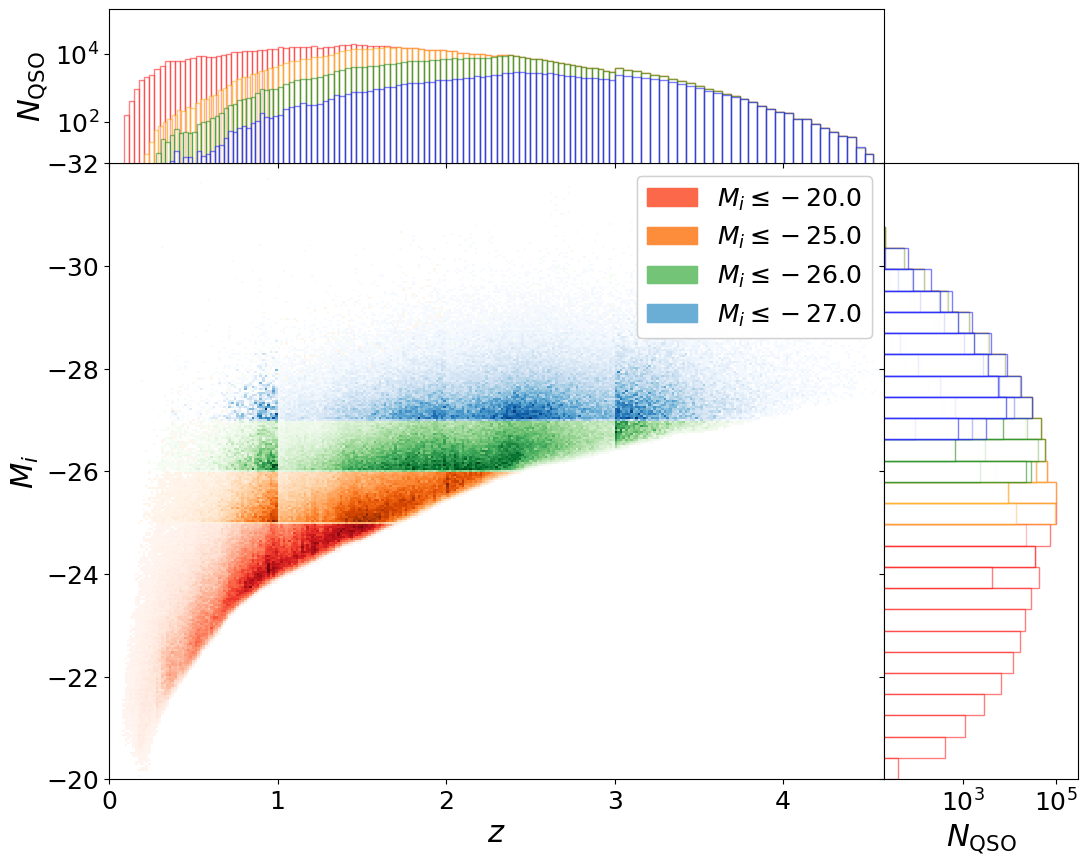

In [33]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)
fac_rand = 25

ax1 = fig.add_subplot(gs[2])
ax2 = fig.add_subplot(gs[0])
ax3 = fig.add_subplot(gs[3])

N = {L: [] for L in L_bins}

for i in range(len(L_bins)):
    
    # N_z = []
    
    for j in z_array:
        
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _, _, _ = quaia.make_bins(G_hi, [j, i], True, ['z', 'L'], 
                                                                                             bins = [z_bins, L_bins], tab_gcat_type = 'data', 
                                                                                              method = ['minmax', 'max'], fac_rand = fac_rand, 
                                                                                              mask = mask*100, percentile = True, n_bins = [None, None])
        quaia.absolute(tab_datahi_mask_zbin0, G_hi)
        h1, xedges, yedges, image = ax1.hist2d(tab_datahi_mask_zbin0['redshift_quaia'], tab_datahi_mask_zbin0['M_i'],
                                               cmap = plt.get_cmap('{}s'.format(colors[i])), bins = [np.linspace(0, 4.6, 300), np.linspace(-32, -20, 300)],
                                               cmin = 1)
        xlim = ax1.get_xlim()
        # ylim = ax1.get_ylim()

        ax2.hist(tab_datahi_mask_zbin0['redshift_quaia'], color = 'white', edgecolor = colors[i], bins = 30, alpha = 0.5)
        ax3.hist(tab_datahi_mask_zbin0['M_i'], color = 'white', edgecolor = colors[i], orientation = 'horizontal', bins = np.linspace(-32, -20, 30), alpha = 0.5, label = '$M_i\leq{}$'.format(L_bins[i]))
        
        # N_z.append(len(tab_datahi_mask_zbin0))
        N[L_bins[i]].append(len(tab_datahi_mask_zbin0))
    
ax1.set_ylabel('$M_i$')
ax1.set_xlabel('$z$')
ax1.set_ylim(-20, -32)
# ax1.set_yscale('log')

ax2.set_ylabel('$N_\mathrm{QSO}$')
ax2.set_yscale('log')
ax2.set_xlim(xlim)
ax2.set_ylim(6,2e5)
ax2.set_xticklabels([])

ax3.set_xlabel('$N_\mathrm{QSO}$')
ax3.set_xscale('log')
# ax3.set_yscale('log')
ax3.set_yticklabels([])
ax3.set_ylim(-20, -32)
ax3.set_xlim(2e1,3e5)
# ax3.legend(loc = 'center right', bbox_to_anchor = (-2.1, 0.8)) #2, 0.75

custom_lines = [mpatches.Patch(color=plt.get_cmap('{}s'.format(colors[i]))(np.array(0.5))) for i in range(len(L_bins))]
second_legend = ax1.legend(custom_lines, ['$M_i\leq{}$'.format(L) for L in L_bins])
fig.add_artist(second_legend)

plt.show()

In [35]:
tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _, _, _ = quaia.make_bins(G_hi, 0, True, 'z', 
                                                                                             bins = [0,4.6], tab_gcat_type = 'data', fac_rand = fac_rand, 
                                                                                              mask = mask*100, percentile = True, n_bins = None)

Leaving tab_gcat_catalog unbinned
Pixels masked by MC but not already by selfunc: 9610
G20.5: 0.28              929347 vs 1295502


In [36]:
quaia.absolute(tab_datahi_mask_zbin0, G_hi)

array([14059.89879616,  8602.85764485, 20667.79640996, ...,
       13102.99125304,  7229.02591058, 12840.07529872])

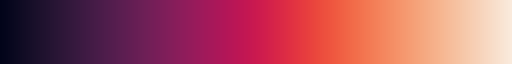

In [38]:
cmap = sns.color_palette("rocket", as_cmap=True)
cmap

In [71]:
L_array = np.array([-32, -27, -26, -25, -20])[::-1]

In [70]:
N

{-20.0: [223881, 464213, 213734, 28436],
 -25.0: [33812, 340587, 213734, 28436],
 -26.0: [8224, 117566, 188436, 28436],
 -27.0: [1254, 24624, 66550, 21464]}

<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2761/4233551018.py:32: SyntaxWarning: invalid escape sequence '\m'
  ax2_hi.set_ylabel('N$_\mathrm{QSO}$')
/tmp/ipykernel_2761/4233551018.py:40: SyntaxWarning: invalid escape sequence '\m'
  ax3_hi.set_xlabel('N$_\mathrm{QSO}$')


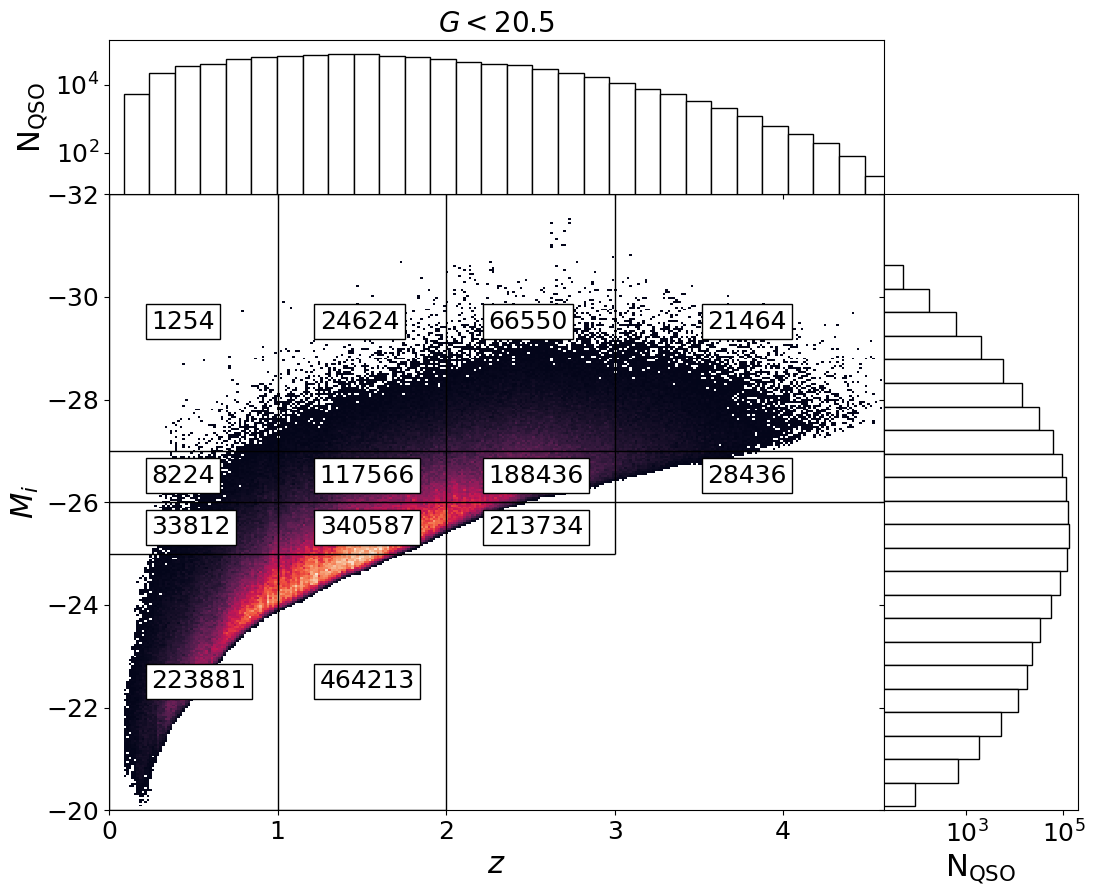

In [117]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)

ax1_hi = fig.add_subplot(gs[2])

h1, xedges, yedges, image = ax1_hi.hist2d(tab_datahi_mask_zbin0['redshift_quaia'], tab_datahi_mask_zbin0['M_i'], cmap = cmap, bins = 300, 
                                       cmin = 1)

for L_bin, xmax in zip(L_array, [z_bins[2], z_bins[3], z_bins[4], z_bins[4], z_bins[4]]):
    ax1_hi.hlines(L_bin, color = 'black', xmin = z_bins[0], xmax = xmax, linewidth = 1)
for z_bin, ymax in zip(z_bins, [L_bins[0], L_bins[0], L_bins[0], L_bins[1], L_bins[2]]):
    ax1_hi.vlines(z_bin, color = 'black', ymin = -32, ymax = ymax, linewidth = 1)
    
for i in z_array:
    for j in range(len(L_bins)):
        # try:
        if ((j<3) and (N[L_bins[j]][i]>N[L_bins[j+1]][i])) or (j ==3):
            ax1_hi.text(quaia.recenter(z_bins)[i]-0.25, quaia.recenter(L_array)[j]+0.125, N[L_bins[j]][i], fontsize = 18, color = 'black', bbox=dict(facecolor='white'))
        # except:
        #     print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_hi, z_bins[i], z_bins[i+1], L_bins[j], 
        #                                                                                               L_bins[j+1]))
ax1_hi.set_ylabel('$M_i$')
xlim = ax1.get_xlim()
ax1_hi.set_xlabel('$z$')
ax1_hi.set_ylim(-20, -32)
ax1_hi.set_xlim(xlim[0], z_bins[-1])

ax2_hi = fig.add_subplot(gs[0])
ax2_hi.hist(tab_datahi_mask_zbin0['redshift_quaia'], color = 'white', edgecolor = 'black', bins = 30)
ax2_hi.set_title('$G<{}$'.format(G_hi))
ax2_hi.set_ylabel('N$_\mathrm{QSO}$')
ax2_hi.set_yscale('log')
ax2_hi.set_xlim(xlim[0], z_bins[-1])
ax2_hi.set_ylim(6,2e5)
ax2_hi.set_xticklabels([])

ax3_hi = fig.add_subplot(gs[3])
ax3_hi.hist(tab_datahi_mask_zbin0['M_i'], color = 'white', edgecolor = 'black', orientation = 'horizontal', bins = 25)
ax3_hi.set_xlabel('N$_\mathrm{QSO}$')
ax3_hi.set_xscale('log')
ax3_hi.set_yticklabels([])
ax3_hi.set_ylim(-20, -32)
ax3_hi.set_xlim(2e1,2e5)

plt.show()

# Implement halo model
## Plot HOD: $\langle N(M) \rangle = \begin{cases}f_{duty} & M\geq M_{min} \\ 0 & M<M_{min}\end{cases}$
### At fixed $f_{duty}$ and $M_{min}$

In [20]:
bins = np.logspace(9, M_max, 79)

In [21]:
M_min_array = [12.86, 12.74, 12.79, 12.82]

In [22]:
fduty = [0.018, 0.022, 0.056, 0.071]
n_m_array = []
for i in z_array:        
    n_m=np.zeros(np.shape(quaia.recenter(bins)))
    n_m[quaia.recenter(bins)>=10**M_min_array[i]]=fduty[i]
    n_m_array.append(n_m)

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_156657/3618045427.py:3: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(quaia.recenter(bins), n_m_array[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1))
/tmp/ipykernel_156657/3618045427.py:6: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$M (M_\odot)$')


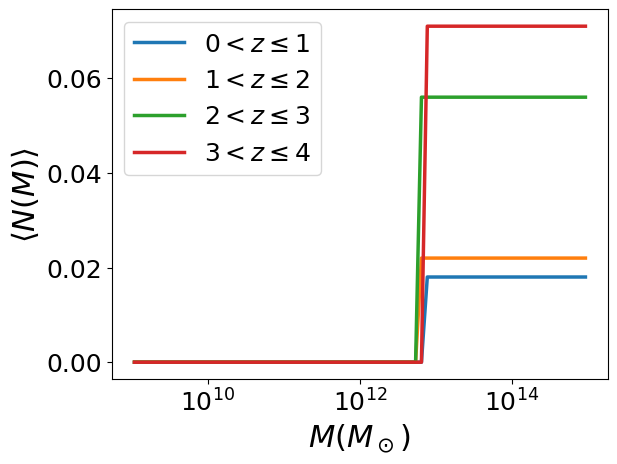

In [23]:
for i in z_array:
        
    plt.plot(quaia.recenter(bins), n_m_array[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1))

plt.xscale('log')
plt.xlabel('$M (M_\odot)$')
plt.ylabel(r'$\langle N(M) \rangle$')
plt.legend()
plt.show()

In [24]:
n_m_array, bins_M_min = [], []
for i in z_array:   
    bins_i = np.logspace(M_min_array[i], M_max, 79)
    n_m=np.ones(np.shape(bins_i))*fduty[i]
    n_m_array.append(n_m)
    bins_M_min.append(bins_i)

In [25]:
n_m_array_2D = []
for i in z_array:

    n_m_array_2D.append([])
    
    for j in range(len(bins)):
        
        n_m=np.ones(np.shape(bins))*fduty[i]
        n_m_array_2D[i].append(n_m)

## Calculate $b_{\mathrm{qq}}(s,z)=\sqrt{\frac{\xi^{(s)}_{\mathrm{qq}}(s)}{\xi^{(r)}_\mathrm{mm}(r)}-\frac{4 \Omega_{\mathrm{m}}^{1.2}(z)}{45}}-\frac{\Omega_{\mathrm{m}}^{0.6}(z)}{3}$
### Use a 50th percentile mask

In [26]:
bins_M_min_array = [np.logspace(np.log10(bins[j]), M_max, 79) for j in range(len(bins))]

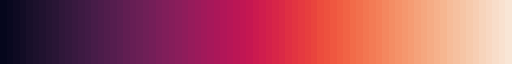

In [27]:
cmap = sns.color_palette("rocket", n_colors = len(bins))
palette = matplotlib.colors.ListedColormap(cmap)
palette

# Calculate derived parameters
## Plot b(z)

In [28]:
def b_eboss(z):
    
    return 0.278*((1+z)**2-6.565) + 2.393

def b_quaia(b_0, a, cosmo = cosmo_planck18): #quaia):
    
    return b_0/ccl.growth_factor(cosmo, a)

In [29]:
b_cf20 = np.load('../results/b_cf20_planck18.npy')
b_wp20 = np.load('../results/b_wp20_planck18.npy')

## Calculate number density as $n_q \approx \int_0^{\infty} d M \frac{d n}{d M}\langle N(M)\rangle$

In [30]:
tab_datahi_mask_zbins, selfunc_hi_bins = [], []
for j in z_array:
    
    tab_datahi_mask_zbin0, _, _, _, _, _, selfunc_hi_bin0, _ = quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)
    tab_datahi_mask_zbins.append(tab_datahi_mask_zbin0['redshift_quaia'])
    selfunc_hi_bins.append(selfunc_hi_bin0)

G20.5_zmin0.0zmax1.0: 0.30              225792 vs 324336
G20.5_zmin1.0zmax2.0: 0.28              467913 vs 648196
G20.5_zmin2.0zmax3.0: 0.24              216828 vs 286508
G20.5_zmin3.0zmax4.6: 0.21              28786 vs 36458


In [31]:
n_q, n_q_err, V_eff, N_q = [], [], [], []

for j in z_array:
    
    N = len(tab_datahi_mask_zbins[j])
    cp = np.percentile(selfunc_hi_bins[j], mask*100)
    f_sky = 1/(4*np.pi)*np.sum(selfunc_hi_bins[j][selfunc_hi_bins[j]>=cp]*hp.nside2pixarea(NSIDE))
    print(f_sky) # f_sky)
    V = f_sky*(Planck18.comoving_volume(z_bins[j+1])-Planck18.comoving_volume(z_bins[j]))*Planck18.h**3/u.h**3
    N_q.append(N)
    n_q.append(N/V.value)
    n_q_err.append(np.sqrt(N)/V.value) # Poisson error
    V_eff.append(V)

0.29746390823822866
0.3229221159273539
0.2744938755620083
0.2518852527362318


In [32]:
fduty_err_hi = 0.002, 0.001, 0.008, 0.077
fduty_err_lo = 0.002, 0.001, 0.007, 0.034

In [33]:
def n_q_theory_err(n_dm, fduty_err, M_min, a, M_min_err, hmf = hmf, cosmo = cosmo_planck18): #quaia):
    
    nm = hmf(cosmo, bins, a)/cosmo['h']**3 # convert to h/Mpc**3
    dn_dm = nm/(bins*np.log(10))
    
    return np.sqrt(n_dm**2*fduty_err**2+(fduty_err*hmf(cosmo, 10**M_min, a))**2*M_min_err**2)

## Limit scales to $30\geq s \geq 80h^{-1}$ Mpc

In [34]:
# Create the bins array
offset = 2.5
delta_max = 40# 64
delta_min = np.min((np.floor((30-0.15)/offset), delta_max))

rmin = 30-delta_min*offset # 0.1 # start higher # 1.4 # 30
rmax = 80+delta_max*offset # 200
nbins = 20 + int(delta_min+delta_max) #90 #20
rbins_chi2 = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'linear'
rbins_chi2, quaia.recenter(rbins_chi2), np.diff(quaia.recenter(rbins_chi2))

(array([  2.5,   5. ,   7.5,  10. ,  12.5,  15. ,  17.5,  20. ,  22.5,
         25. ,  27.5,  30. ,  32.5,  35. ,  37.5,  40. ,  42.5,  45. ,
         47.5,  50. ,  52.5,  55. ,  57.5,  60. ,  62.5,  65. ,  67.5,
         70. ,  72.5,  75. ,  77.5,  80. ,  82.5,  85. ,  87.5,  90. ,
         92.5,  95. ,  97.5, 100. , 102.5, 105. , 107.5, 110. , 112.5,
        115. , 117.5, 120. , 122.5, 125. , 127.5, 130. , 132.5, 135. ,
        137.5, 140. , 142.5, 145. , 147.5, 150. , 152.5, 155. , 157.5,
        160. , 162.5, 165. , 167.5, 170. , 172.5, 175. , 177.5, 180. ]),
 array([  3.75,   6.25,   8.75,  11.25,  13.75,  16.25,  18.75,  21.25,
         23.75,  26.25,  28.75,  31.25,  33.75,  36.25,  38.75,  41.25,
         43.75,  46.25,  48.75,  51.25,  53.75,  56.25,  58.75,  61.25,
         63.75,  66.25,  68.75,  71.25,  73.75,  76.25,  78.75,  81.25,
         83.75,  86.25,  88.75,  91.25,  93.75,  96.25,  98.75, 101.25,
        103.75, 106.25, 108.75, 111.25, 113.75, 116.25, 118.75, 121.25

## Compute the maximum number of jackknife regions

In [35]:
for j in z_array:
    
    N = len(tab_datahi_mask_zbins[j])
    cp = np.percentile(selfunc_hi_bins[j], mask*100)
    f_sky = 1/(4*np.pi)*np.sum(selfunc_hi_bins[j][selfunc_hi_bins[j]>=cp]*hp.nside2pixarea(NSIDE))
    V = f_sky*(Planck18.comoving_volume(j+1)-Planck18.comoving_volume(j))*Planck18.h**3/u.h**3
    V_jackknife = f_sky*(4/3*np.pi*(rmax**3))*V.unit
    print(np.int(V/V_jackknife), (V/25)**(1/3))

2079 845.5005360132403 Mpc / h
5864 1227.6953277765404 Mpc / h
6668 1213.8962546845646 Mpc / h
6319 1158.656565782417 Mpc / h


In [36]:
cf_chi2, cf_matter_chi2 = [], []
yerr_cf_chi2, b_cf_chi2 = [], []
b_cf_q_chi2 = []
a_zbin = []
H0 = Planck18.H0 # cosmo_planck18['H0'] * u.km/u.s/u.Mpc
    
for j in z_array:

    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _, _ = quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)

    # quasar correlation function
    cf, qq, qr = quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
               rbins = rbins_chi2, Om0 = Planck18.Om0, h = Planck18.h, error = True)
    cf_chi2.append(cf)

    # scale factor
    a = a_median(tab_datahi_mask_zbin0)
    a_zbin.append(a)

    # matter correlation function
    rbins_Mpc = (quaia.recenter(rbins_chi2)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))
    cf_matter = ccl.correlations.correlation_3d(cosmo_planck18, r=rbins_Mpc, a=a)
    cf_matter_chi2.append(cf_matter)

    # effective bias 
    b = np.sqrt(cf/cf_matter)
    b_cf_chi2.append(b)

    # yerr
    yerr=(1+cf)/np.sqrt(qq)
    yerr[cf<0]=np.sqrt((1+b**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
    yerr_cf_chi2.append(yerr)

    # qso bias
    b_cf_q_chi2.append(b_qso(cf, cf_matter, ccl.growth_rate(cosmo_planck18, a)))

G20.5_zmin0.0zmax1.0: 0.30              225792 vs 324336


[Warning] The CPU supports AVX512F but the compiler does not.  Can you try another compiler?
/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_156657/1897172956.py:29: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_156657/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


G20.5_zmin1.0zmax2.0: 0.28              467913 vs 648196


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_156657/1897172956.py:29: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_156657/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


G20.5_zmin2.0zmax3.0: 0.24              216828 vs 286508


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_156657/1897172956.py:29: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_156657/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


G20.5_zmin3.0zmax4.6: 0.21              28786 vs 36458


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_156657/1897172956.py:29: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_156657/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


In [37]:
rpmask = (quaia.recenter(rbins_chi2) >= 30) & (quaia.recenter(rbins_chi2) <= 80)

# Perform nested sampling with dynesty

In [38]:
# Define the dimensionality of our problem.
ndim = 2

## Pick cosmology

In [39]:
cosmo = 'Planck'

In [150]:
N = 80

In [151]:
# Define our 3-D correlated multivariate normal log-likelihood.
# C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25.npy'.format(G_hi, 30, 80, 20, j)) # very bad
# C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25_Planck.npy'.format(G_hi, 30, 80, 20, j)) # good
# C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N25_cosmo_planck18.npy'.format(G_hi, 30, 80, 20, z_bins[j], z_bins[j+1])) # bad
# C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25_{}.npy'.format(G_hi, rmin, rmax, nbins, j, cosmo)) # [np.ix_([False]+[True]*20+[False], [False]+[True]*20+[False])] # very good
# C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N25_{}.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], cosmo)) # bad
C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good

# C[C==0] = 0.95
ix_grid = np.ix_(rpmask, rpmask)
    
def loglike(x, a, cf_matter, C, cf, n_q, nbins, cosmo = cosmo_planck18, error = 0.05):
    
    fduty, M_min = x
    
    bins_m = np.logspace(M_min, M_max, 79)
    n_m=np.ones(np.shape(bins_m))*10**fduty
    # n_m=np.ones(np.shape(bins_m))*fduty
        
    cf_2h_zbin, _ = cf_2h(bins_m, n_m, a, cosmo, cf_matter, recenter = False)
    delta = cf-cf_2h_zbin
    
    Cinv = np.linalg.inv(C)
    lnorm = -0.5 * (np.log(2 * np.pi) * nbins +
                    np.log(np.linalg.det(C)))
    
    n_q_theory = M(bins_m, n_m, a = a, cosmo = cosmo, recenter = False)[1]
    penalty = np.abs(n_q_theory-n_q)/n_q
    if penalty > error:
        penalty = np.inf
    
    return -0.5 * np.dot(delta, np.dot(Cinv, delta)) + lnorm - penalty

In [152]:
def ptform(u):
    """Transforms the uniform random variables `u ~ Unif[0., 1.)`
    to the parameters of interest."""

    x = np.array(u)  # copy u 

    # Uniform from 0 to 1
    # x[0] = u[0] # should this also be uniform in log?
    x[0] =  6* u[0] - 6 # scale and shift to [-6., 0.)


    # Uniform from 9 to 15
    x[1] = 6 * u[1] + 9  # scale and shift to [9., 15.)

    return x

In [153]:
# initialize our nested sampler
sampler = NestedSampler(loglike, ptform, ndim, logl_args=[a_zbin[j], cf_matter_chi2[j][rpmask], C[ix_grid], cf_chi2[j][rpmask], n_q[j], nbins])

In [154]:
# run the sampler with checkpointing
sampler.run_nested(dlogz = 0.005)
results = sampler.results

3867it [00:09, 392.22it/s, +500 | bound: 17 | nc: 1 | ncall: 32840 | eff(%): 13.503 | loglstar:   -inf < -23.404 <    inf | logz: -30.474 +/-    nan | dlogz:  0.000 >  0.005]


In [155]:
# Print out a summary of the results.
results.summary()

Summary
nlive: 500
niter: 3867
ncall: 9340
eff(%): 13.503
logz: -30.474 +/-  0.114


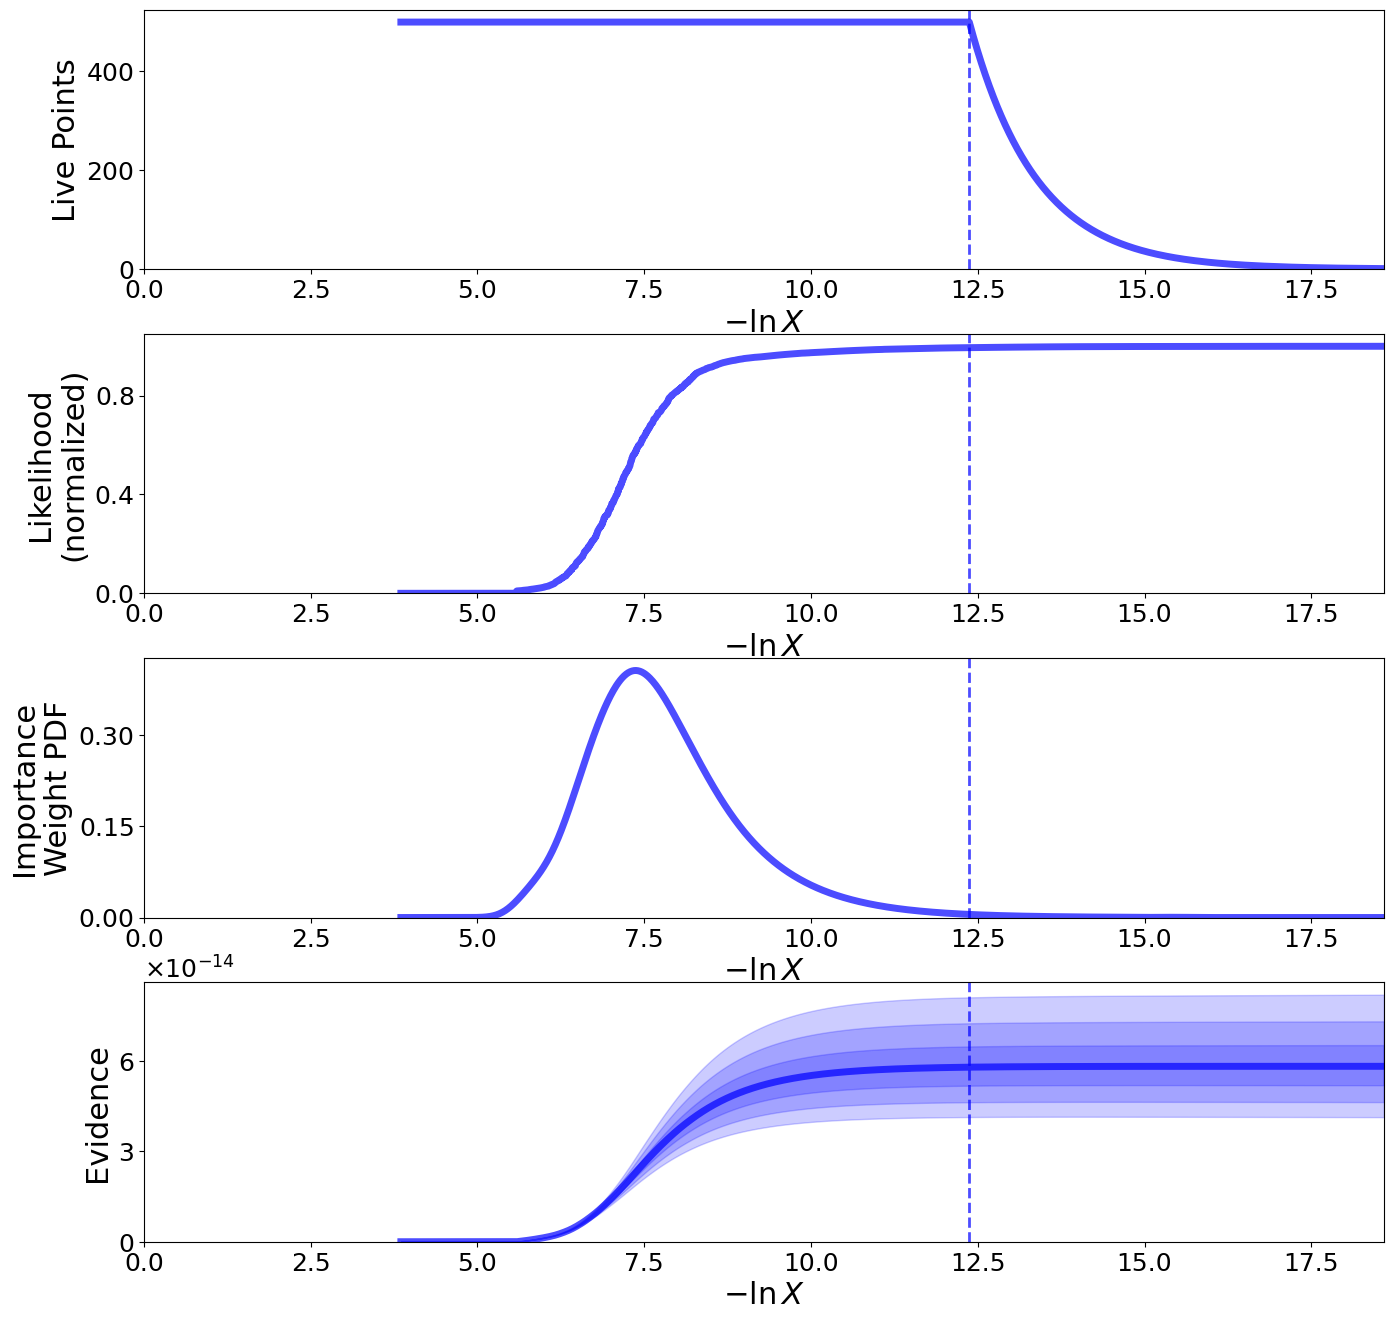

In [156]:
# lnz_truth = ndim * -np.log(2 * 10.)  # analytic evidence solution
fig, axes = dyplot.runplot(results)  # summary (run) plot
fig.subplots_adjust(hspace=0.25)

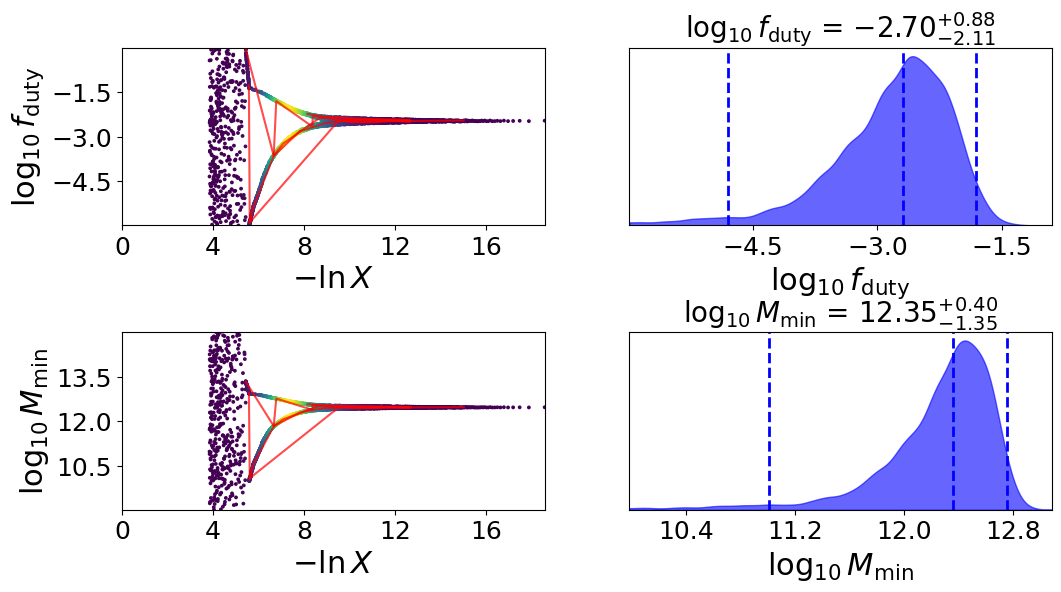

In [157]:
fig, axes = dyplot.traceplot(results, 
                             # truths=np.zeros(ndim),
                             # truth_color='black', 
                             show_titles=True,
                             trace_cmap='viridis', connect=True,
                             connect_highlight=range(5), labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$'])
fig.subplots_adjust(hspace=0.6)

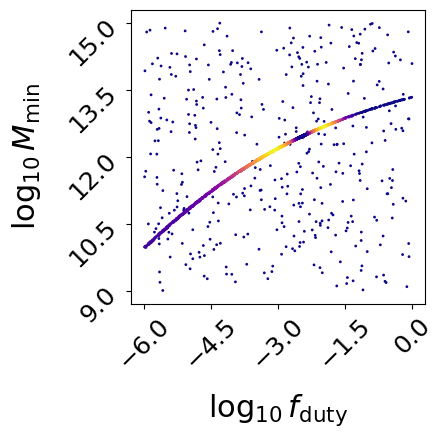

In [158]:
# initialize figure
fig, axes = plt.subplots(1, 1, figsize=(5, 5))
# axes = axes.reshape((2, 2))  # reshape axes

# add white space
# [a.set_frame_on(False) for a in axes[:, 2]]
# [a.set_xticks([]) for a in axes[:, 2]]
# [a.set_yticks([]) for a in axes[:, 2]]

# plot initial run (res1; left)
fg, ax = dyplot.cornerpoints(results, cmap='plasma',
                             # truths=np.zeros(ndim),
                             kde=False, labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$'], fig=(fig, axes))

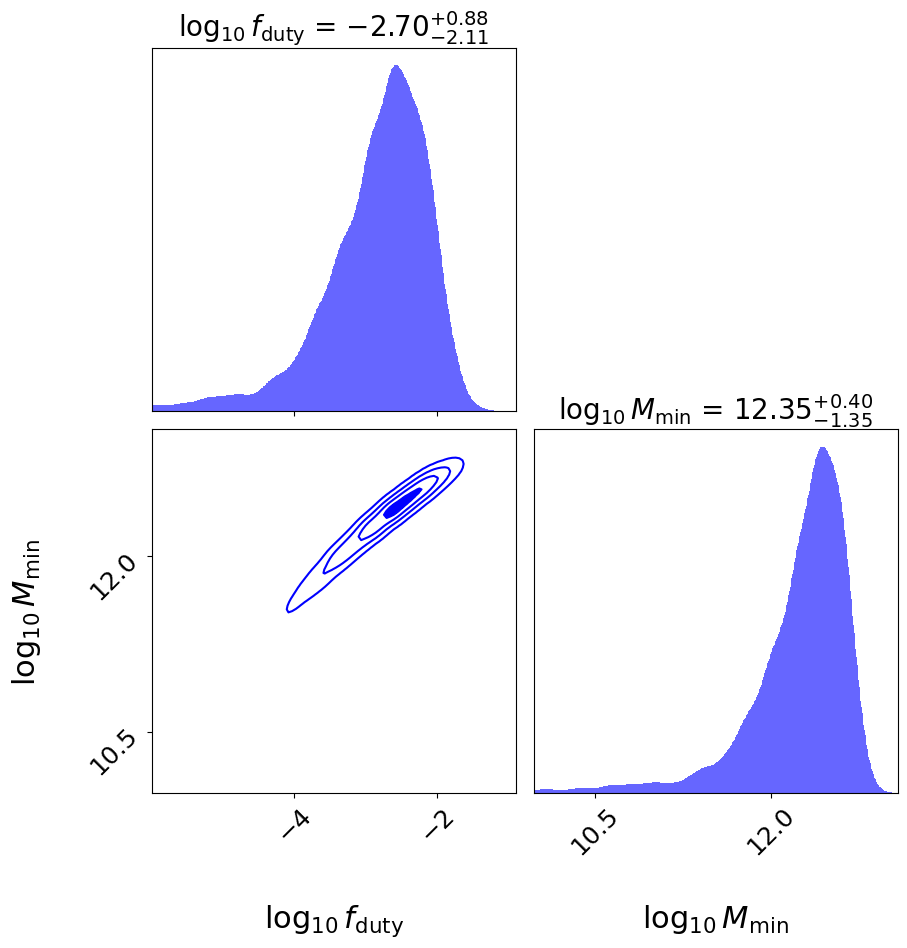

In [159]:
# # initialize figure
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
# axes = axes.reshape((3, 7))  # reshape axes

# # add white space
# [a.set_frame_on(False) for a in axes[:, 3]]
# [a.set_xticks([]) for a in axes[:, 3]]
# [a.set_yticks([]) for a in axes[:, 3]]

# plot initial run (res1; left)
fg, ax = dyplot.cornerplot(results, color='blue', truths=np.zeros(ndim),
                           truth_color='black', show_titles=True,
                           max_n_ticks=3, quantiles=None, labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$'], fig=(fig, axes[:, :3]))
# fg.subplots_adjust(wspace=0.15, hspace=0.15)
# fg.subplots_adjust(hspace=0.3)

In [160]:
samples, weights = results.samples, results.importance_weights()
mean, cov = dyfunc.mean_and_cov(samples, weights)
print(mean, cov)

[-2.84288193 12.24586513] [[0.52803972 0.30532051]
 [0.30532051 0.17981604]]


In [161]:
# Compute weighted quantiles
# weights = np.exp(results.logwt - results.logz[-1])
# samples = results.samples
samples, weights = results.samples, results.importance_weights()

# Get median and 1-sigma (16th, 50th, 84th percentiles) for each parameter
quantiles = [dyfunc.quantile(samples[:, i], [0.025, 0.5, 0.975], weights=weights) 
             for i in range(samples.shape[1])]
labels = ['log10(f_duty)', 'log10(M_min)']

for i, (lo, mid, hi) in enumerate(quantiles):
    print(f"{labels[i]}: {mid:.2f} + {hi-mid:.2f}/-{mid-lo:.2f}")

log10(f_duty): -2.70 + 0.88/-2.11
log10(M_min): 12.35 + 0.40/-1.35


## Across all $z$

4539it [00:10, 438.81it/s, +500 | bound: 19 | nc: 1 | ncall: 25836 | eff(%): 19.889 | loglstar:   -inf < 29.589 <    inf | logz: 21.570 +/-    nan | dlogz:  0.000 >  0.005]


Summary
nlive: 500
niter: 4539
ncall: 9836
eff(%): 19.889
logz: 21.570 +/-  0.124
0<z<=1
log10(f_duty): -2.54 + 0.11/-0.11
log10(M_min): 12.13 + 0.11/-0.11



4688it [00:10, 447.79it/s, +500 | bound: 20 | nc: 1 | ncall: 30756 | eff(%): 17.147 | loglstar:   -inf < 22.976 <    inf | logz: 14.404 +/-    nan | dlogz:  0.000 >  0.005]


Summary
nlive: 500
niter: 4688
ncall: 10256
eff(%): 17.147
logz: 14.404 +/-  0.128
1<z<=2
log10(f_duty): -2.71 + 0.08/-0.09
log10(M_min): 12.01 + 0.07/-0.08



4512it [00:10, 440.62it/s, +500 | bound: 19 | nc: 1 | ncall: 30031 | eff(%): 16.972 | loglstar:   -inf < 24.173 <    inf | logz: 16.008 +/-    nan | dlogz:  0.000 >  0.005]


Summary
nlive: 500
niter: 4512
ncall: 10031
eff(%): 16.972
logz: 16.008 +/-  0.125
2<z<=3
log10(f_duty): -2.59 + 0.14/-0.14
log10(M_min): 12.12 + 0.09/-0.10



3879it [00:09, 423.73it/s, +500 | bound: 17 | nc: 1 | ncall: 31046 | eff(%): 14.336 | loglstar:   -inf < -23.404 <    inf | logz: -30.438 +/-    nan | dlogz:  0.000 >  0.005]


Summary
nlive: 500
niter: 3879
ncall: 9046
eff(%): 14.336
logz: -30.438 +/-  0.114
3<z<=4
log10(f_duty): -2.75 + 0.55/-0.73
log10(M_min): 12.33 + 0.25/-0.40



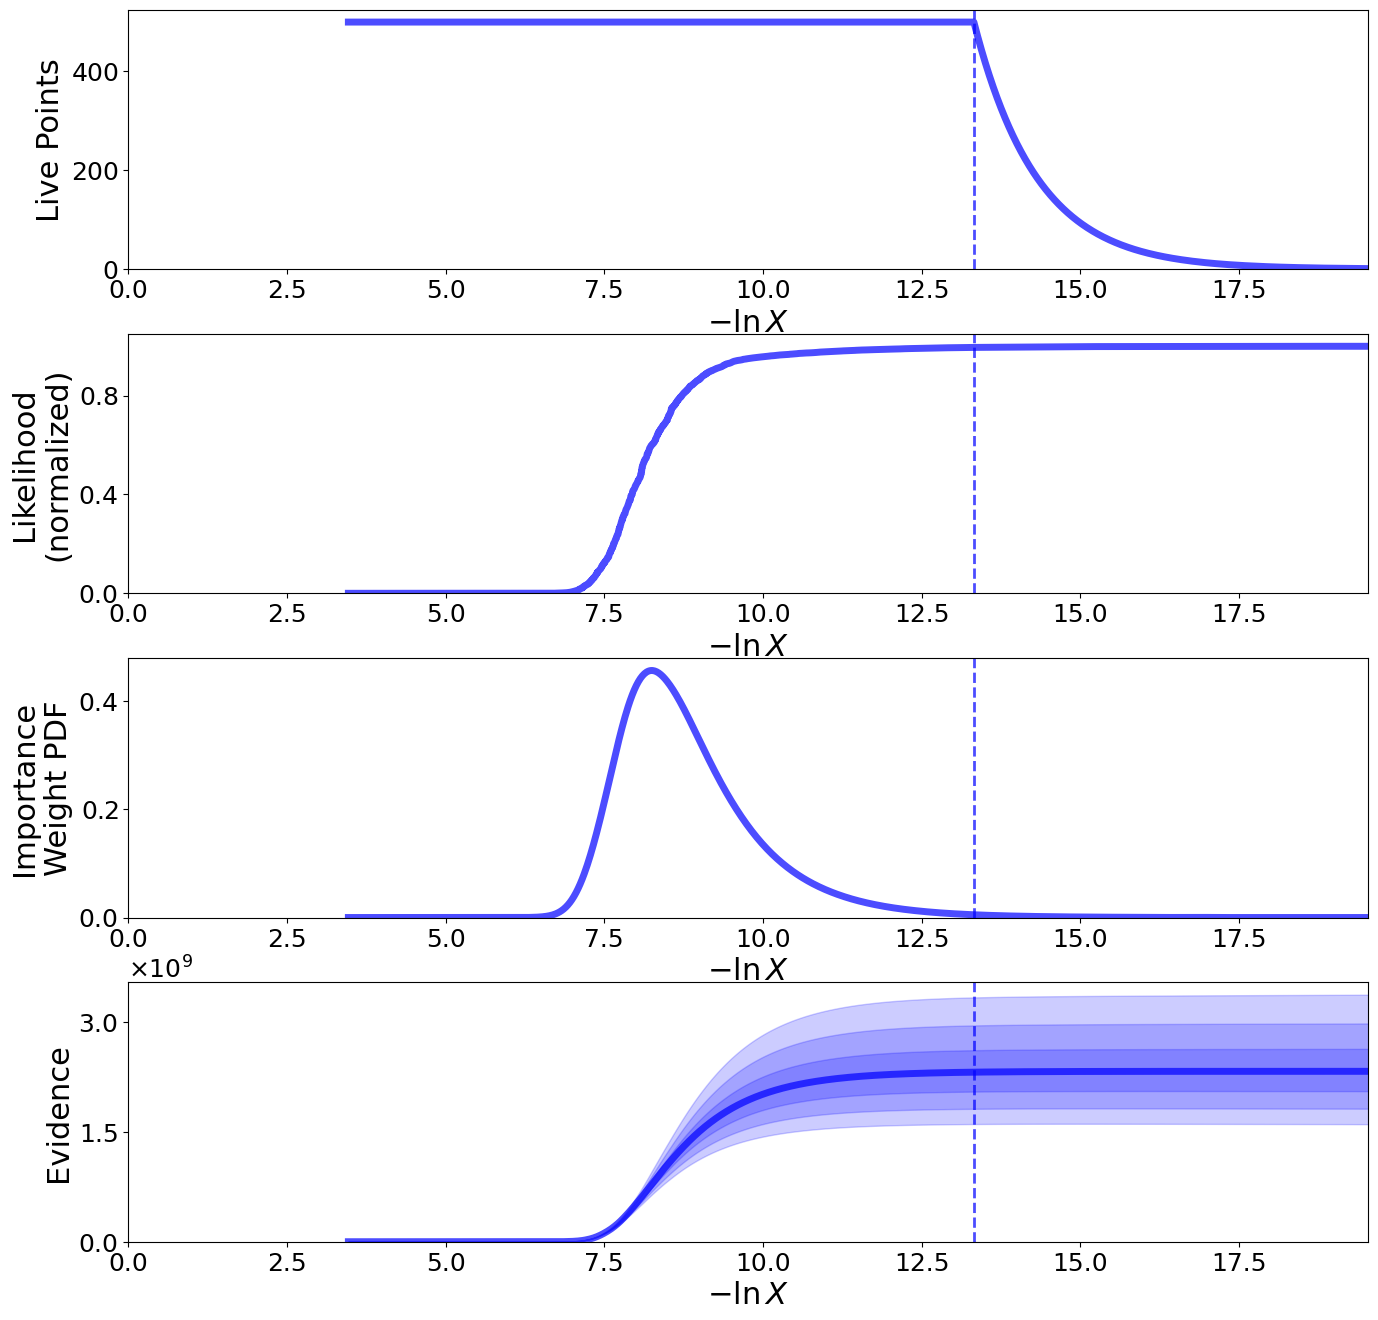

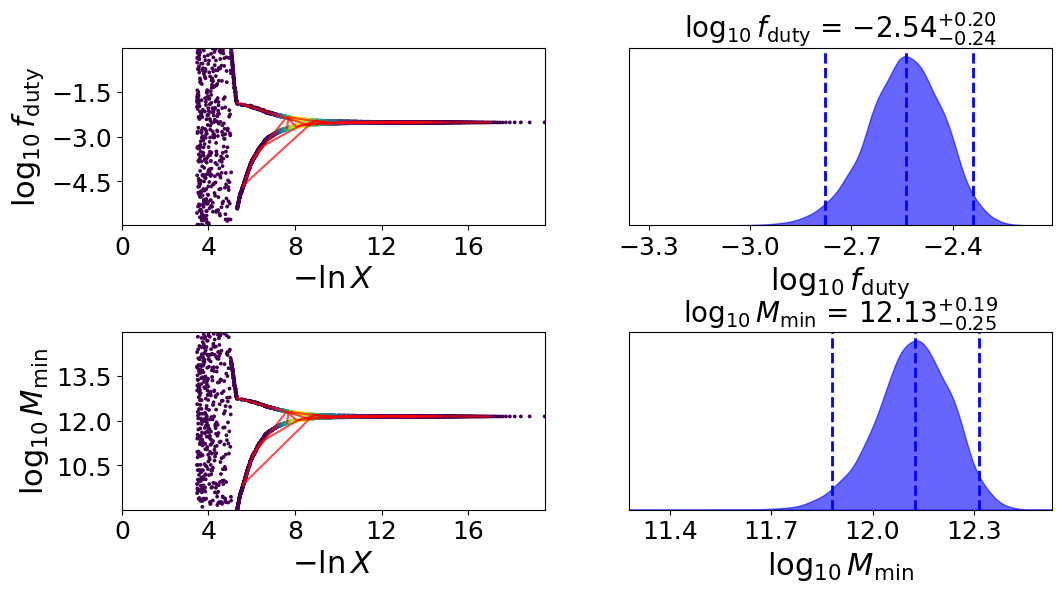

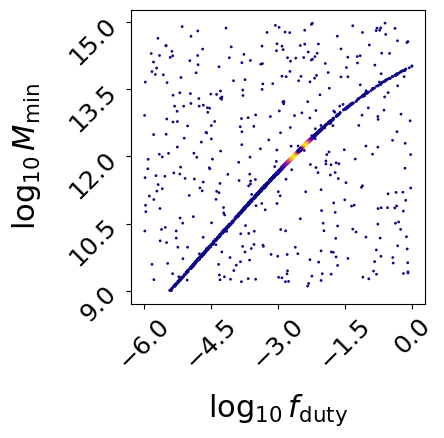

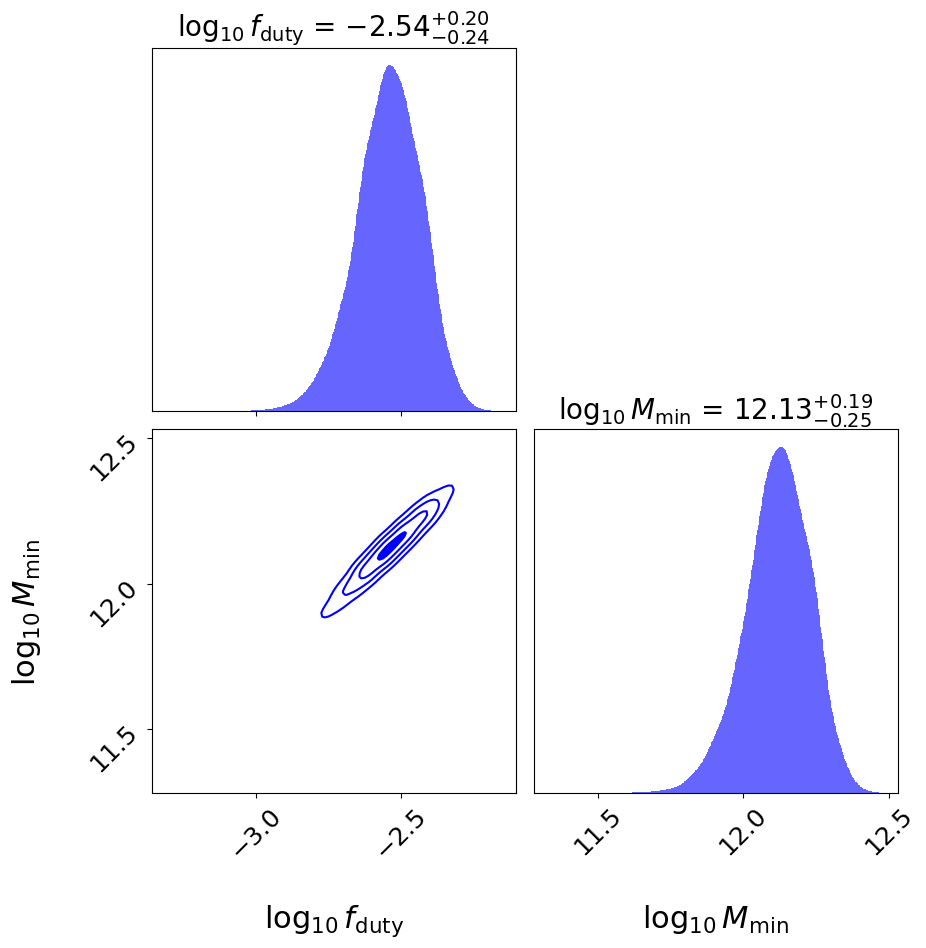

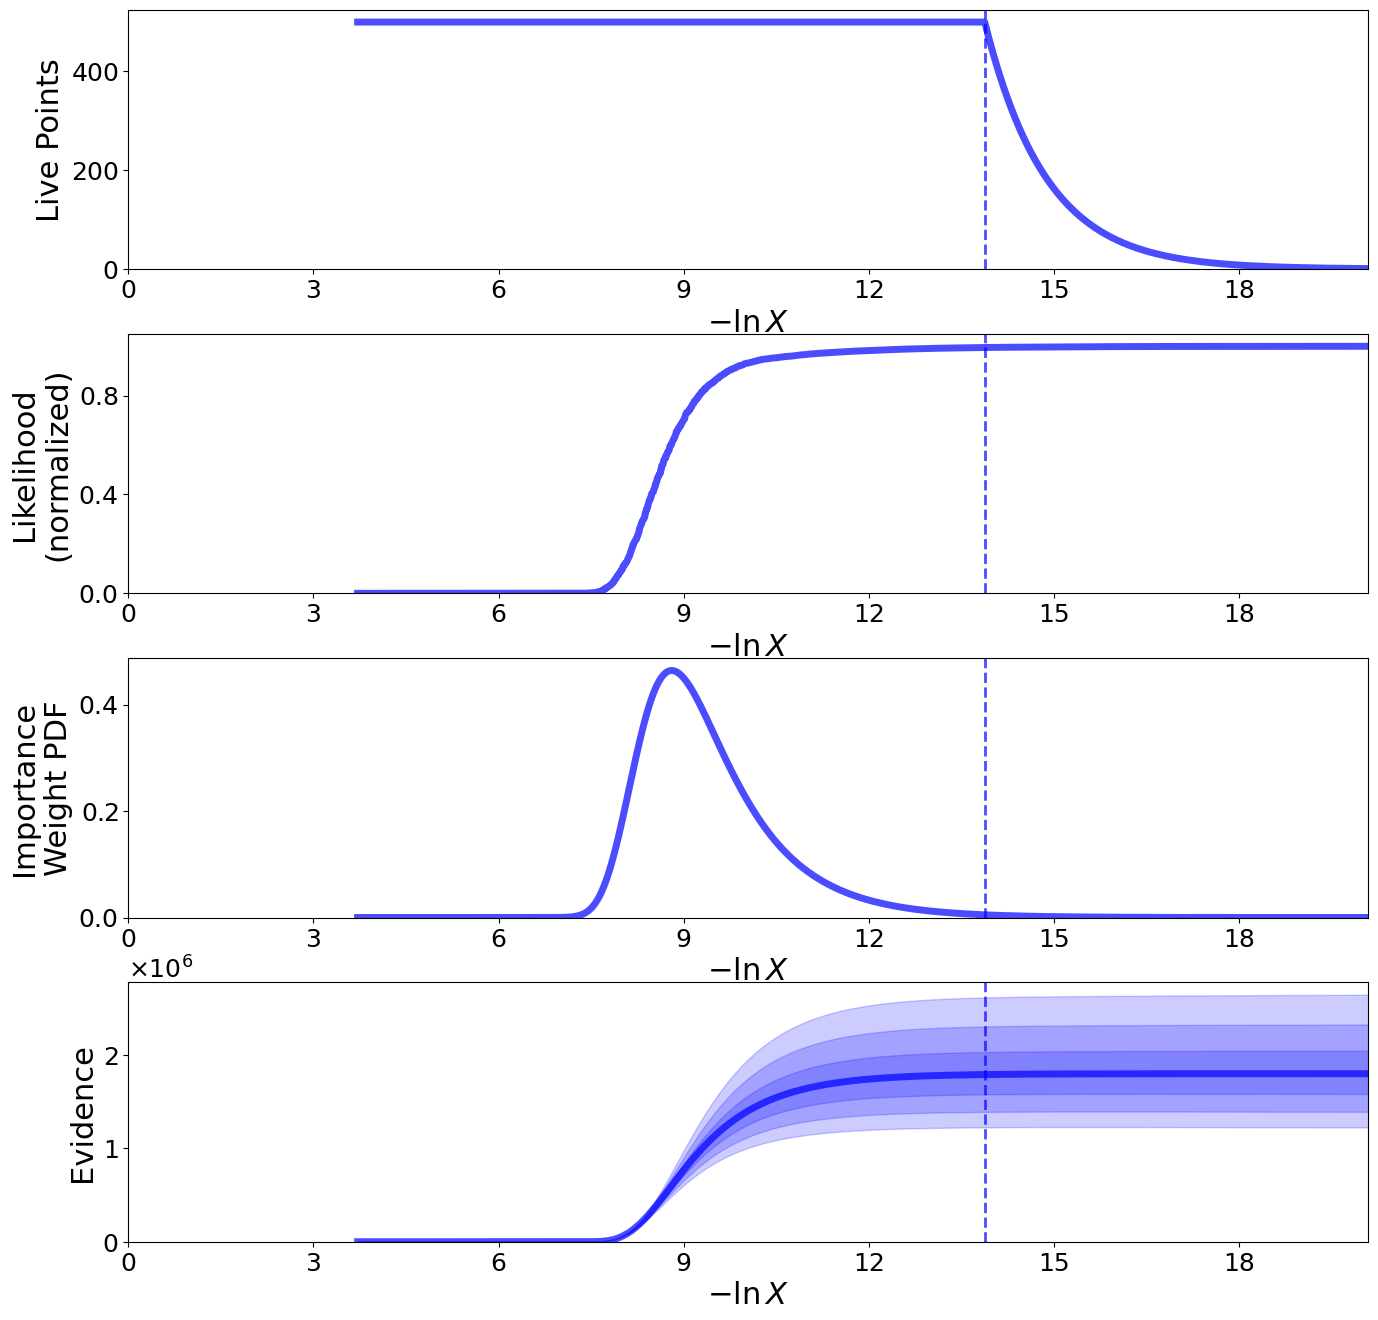

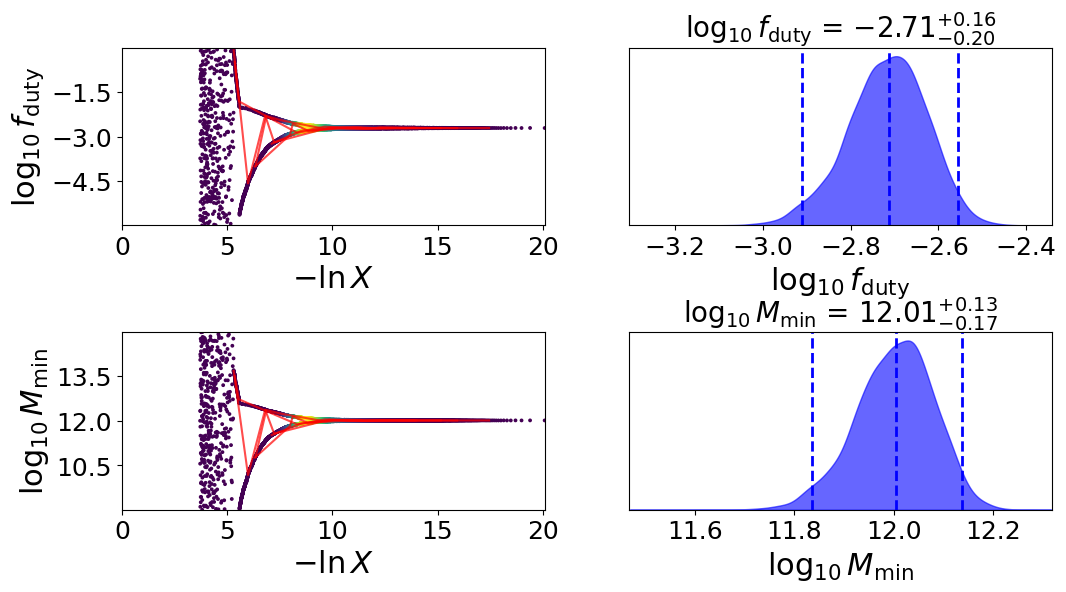

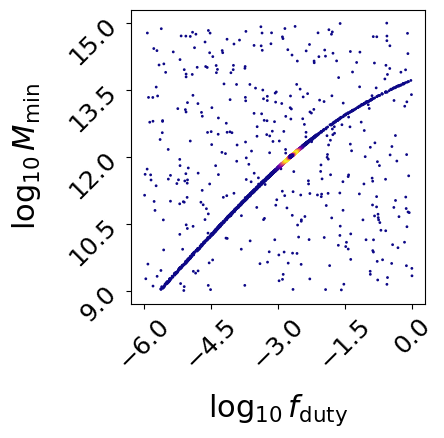

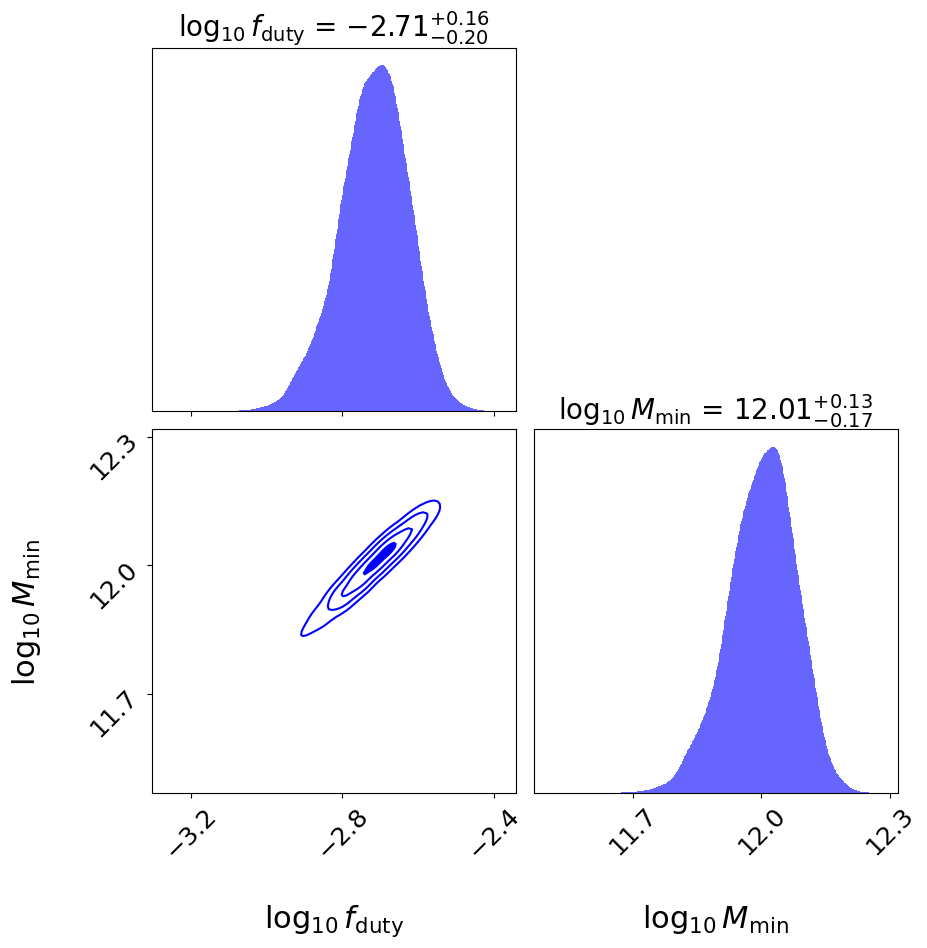

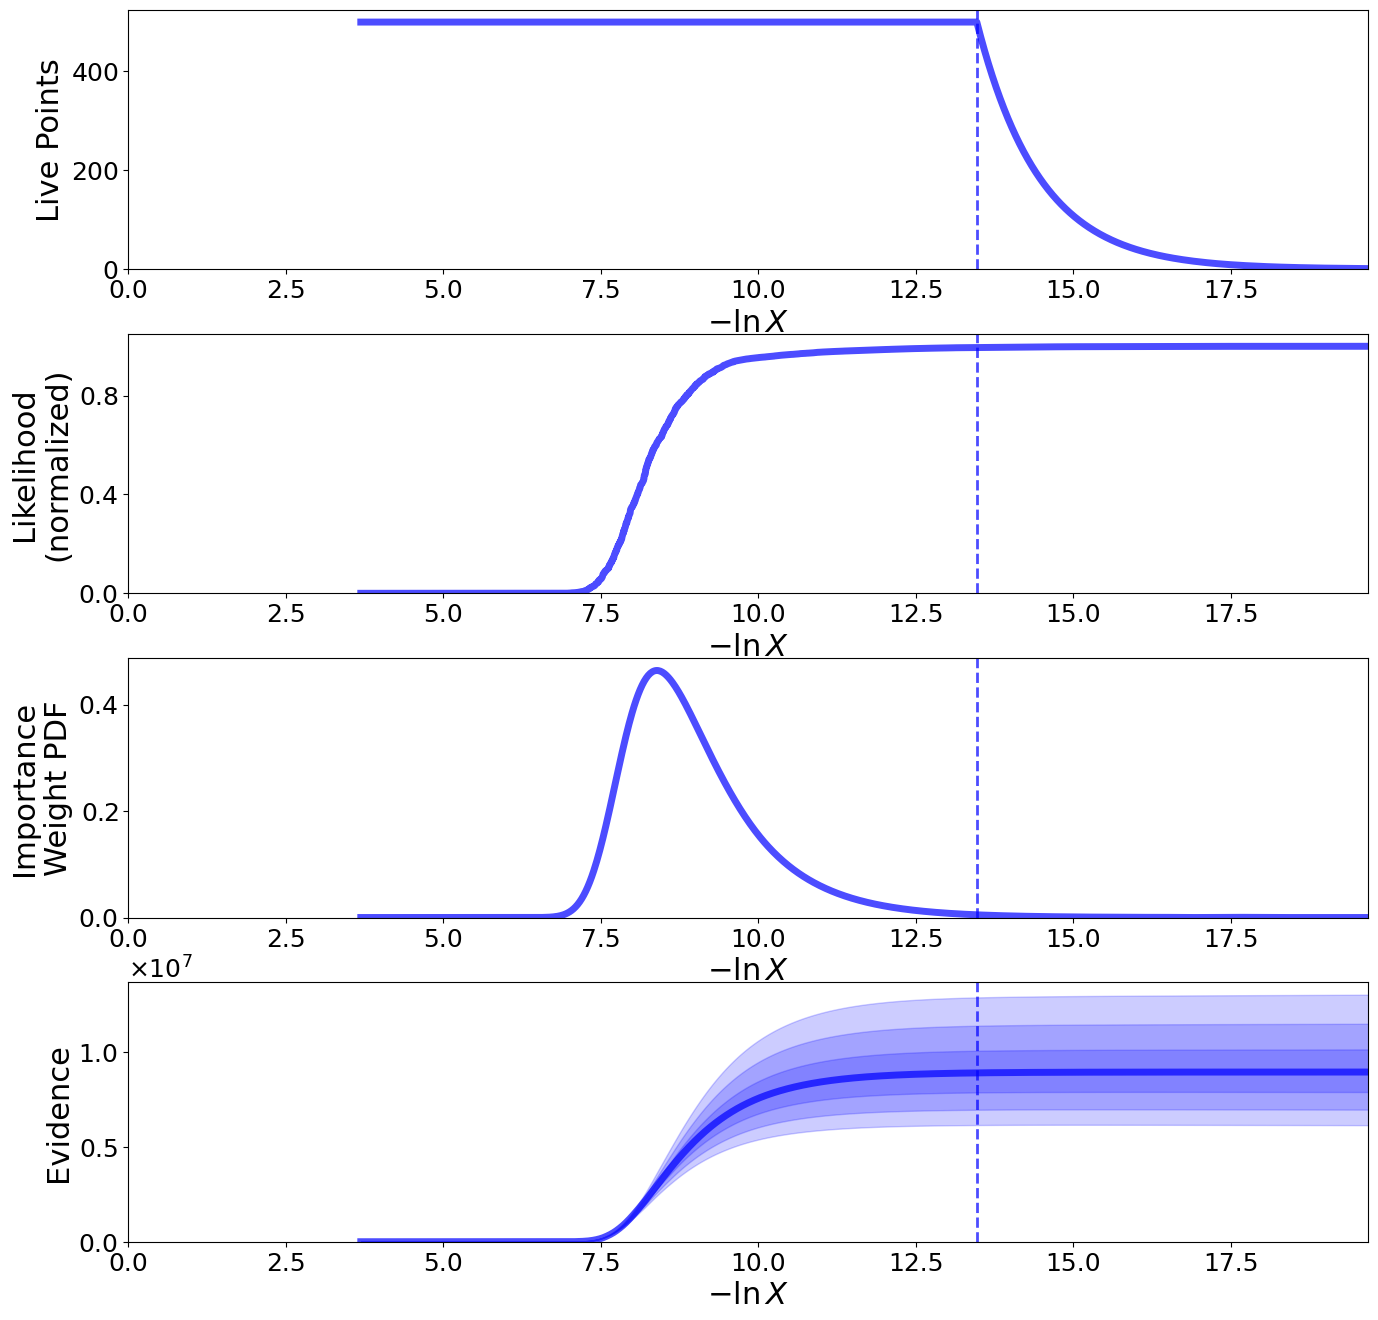

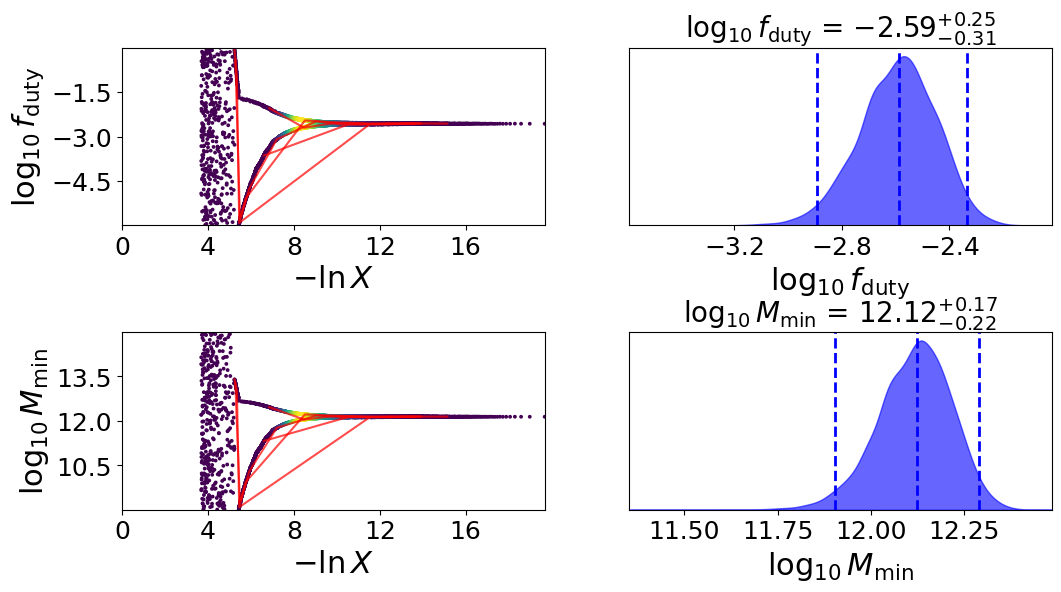

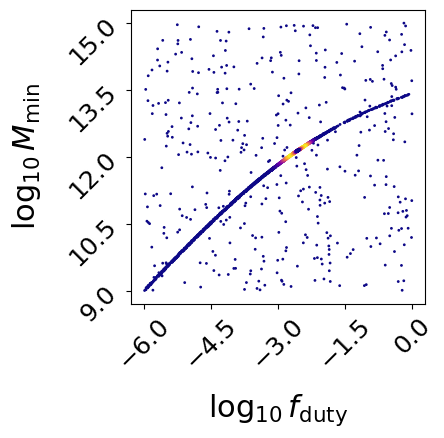

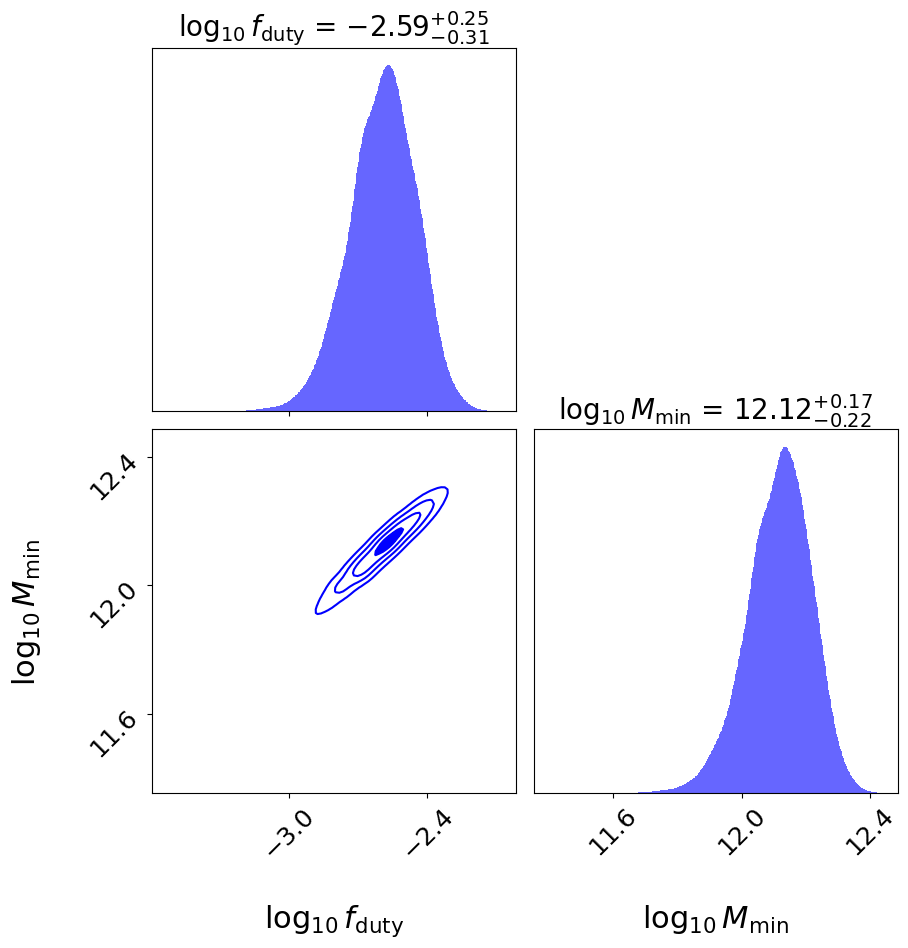

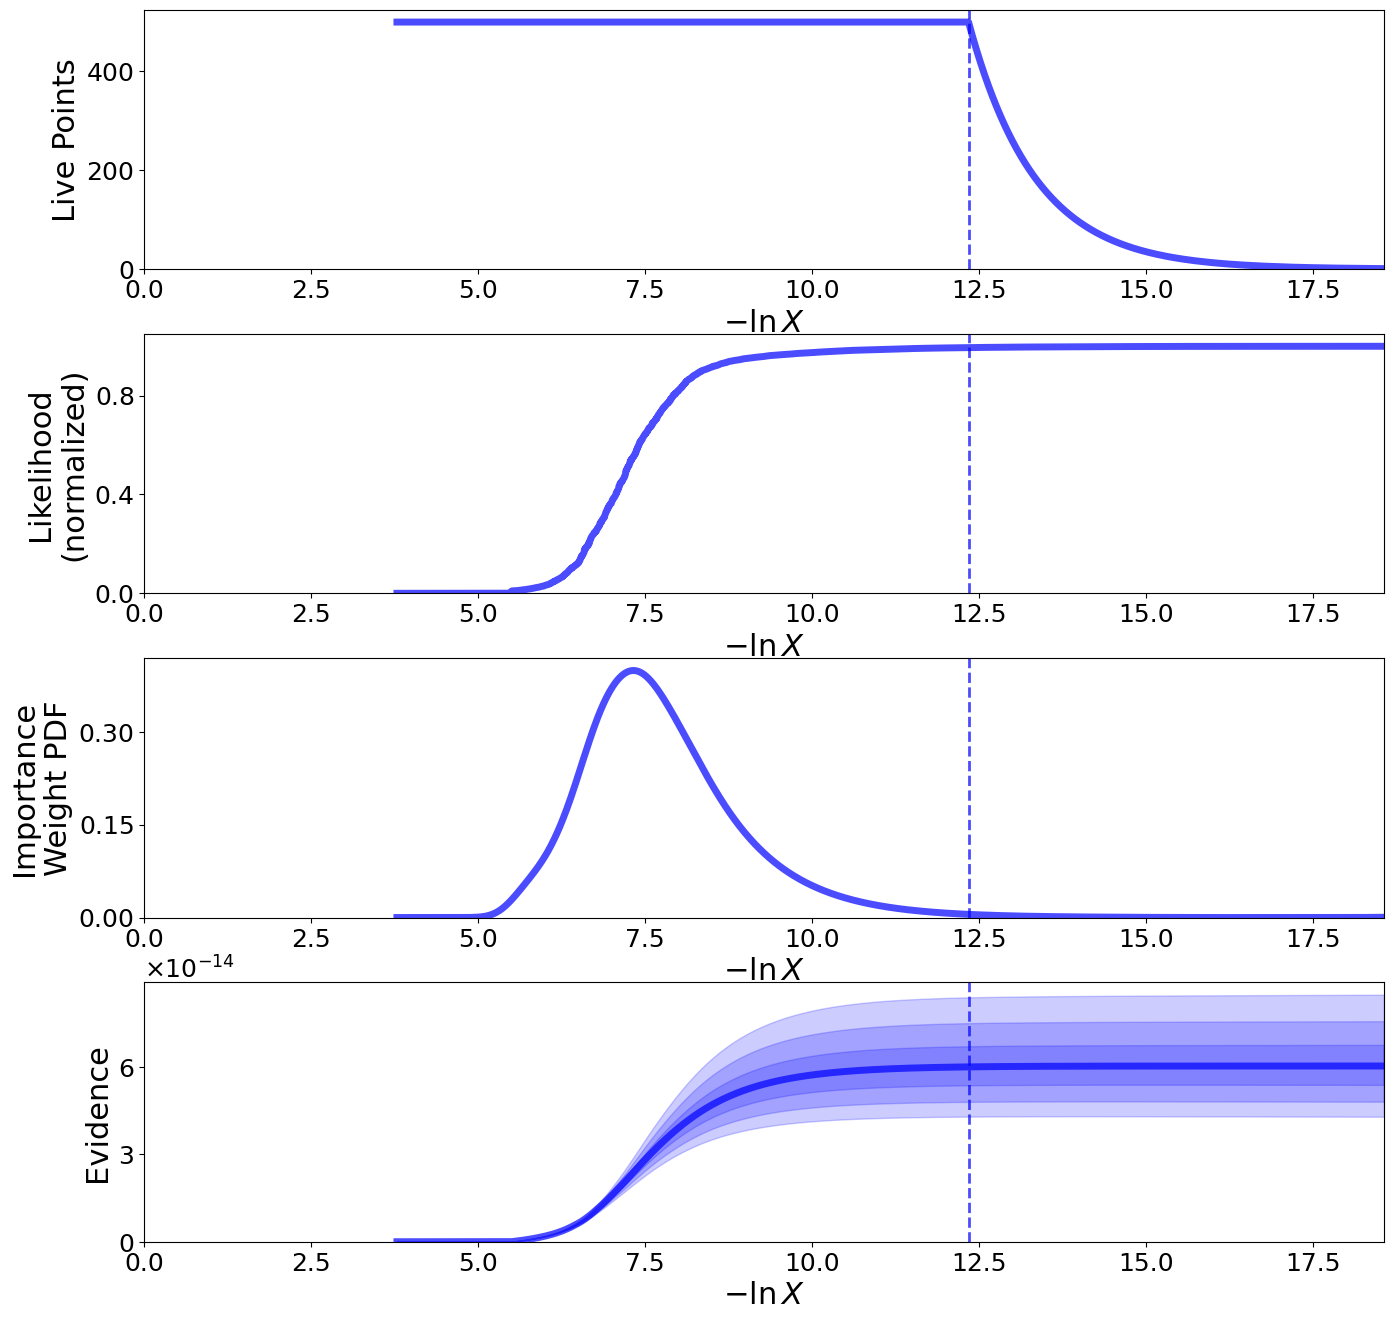

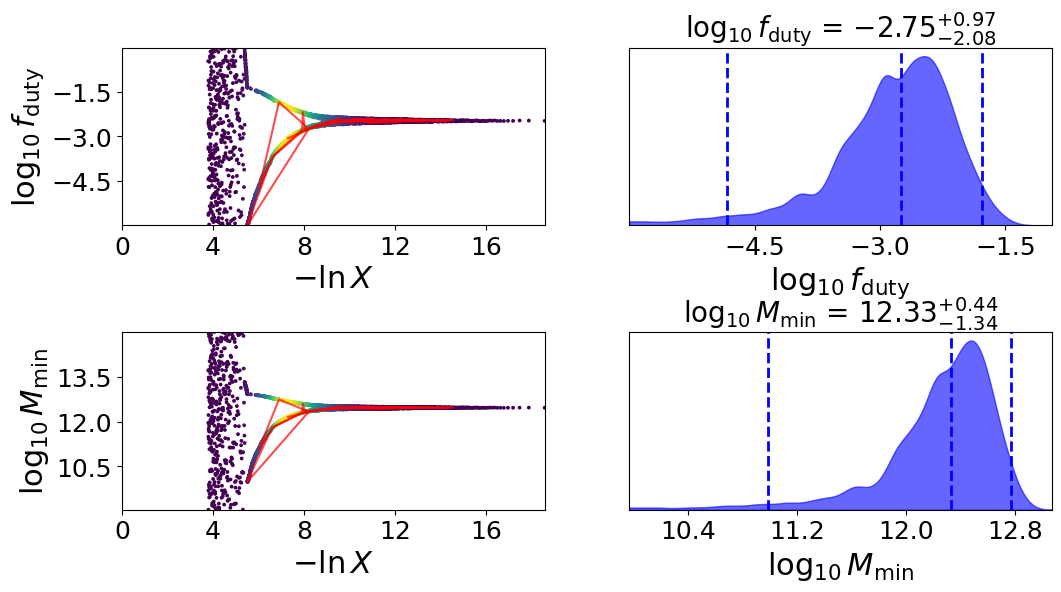

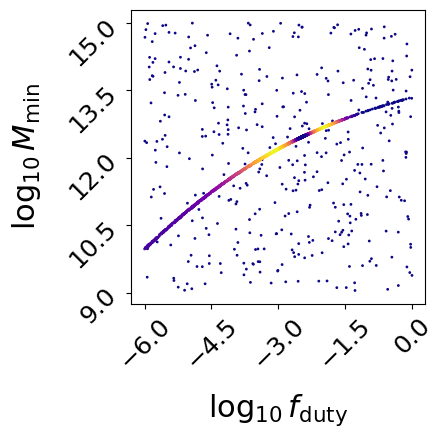

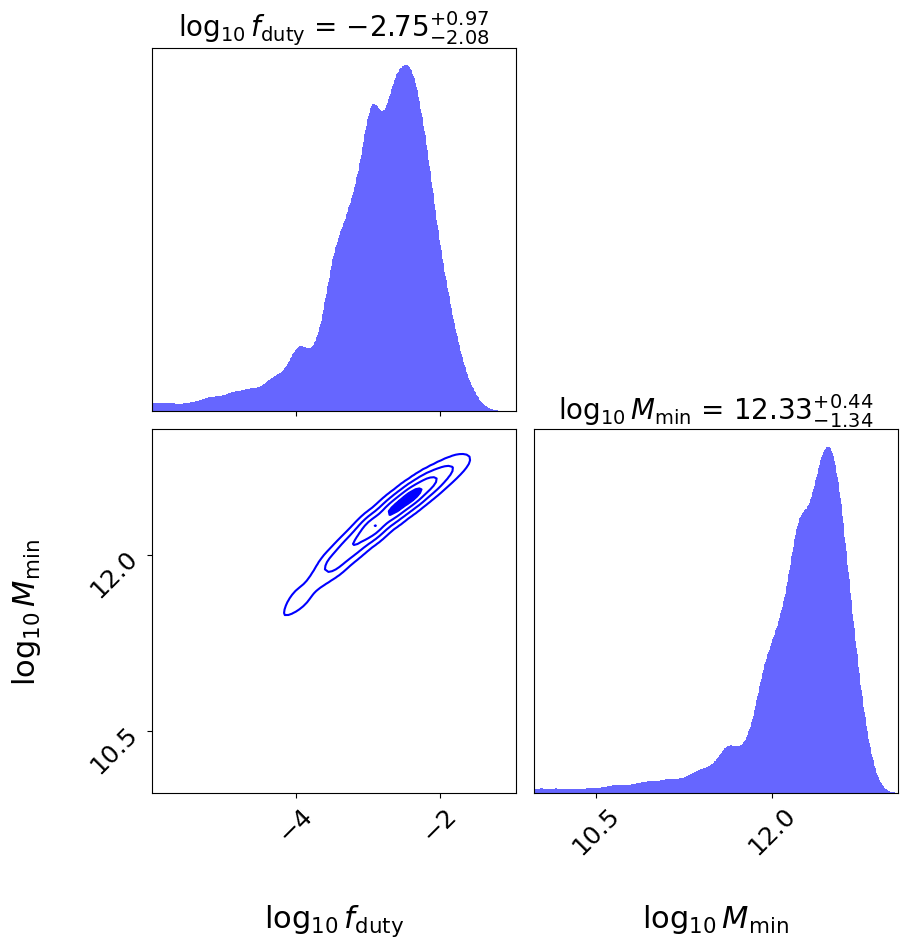

In [162]:
f_duty, M_min = [], []
# f_duty_hi, M_min_hi, f_duty_lo, M_min_lo = [], [], [], []
labels = ['log10(f_duty)', 'log10(M_min)']
err = {i: [] for i in labels}
f_duty_samples, M_min_samples = [], []
for j in z_array:
    
    # C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25.npy'.format(G_hi, 30, 80, 20, j))
    # C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25_{}.npy'.format(G_hi, rmin, rmax, nbins, j, cosmo)) # [np.ix_([False]+[True]*20+[False], [False]+[True]*20+[False])] # very good
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good
    ix_grid = np.ix_(rpmask, rpmask)

    # initialize our nested sampler
    sampler = NestedSampler(loglike, ptform, ndim, logl_args=[a_zbin[j], cf_matter_chi2[j][rpmask], C[ix_grid], cf_chi2[j][rpmask], n_q[j], nbins])
    
    # run the sampler with checkpointing
    sampler.run_nested(dlogz = 0.005)
    results = sampler.results
    
    # Print out a summary of the results.
    results.summary()
    
    fig, axes = dyplot.runplot(results)  # summary (run) plot
    fig.subplots_adjust(hspace=0.25)
    
    fig, axes = dyplot.traceplot(results, 
                             show_titles=True,
                             trace_cmap='viridis', connect=True,
                             connect_highlight=range(5), labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$'])
    fig.subplots_adjust(hspace=0.6)
    
    # initialize figure
    fig, axes = plt.subplots(1, 1, figsize=(5, 5))

    # plot initial run (res1; left)
    fg, ax = dyplot.cornerpoints(results, cmap='plasma',
                                 kde=False, labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$'], fig=(fig, axes))
    
    # initialize figure
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))

    # plot initial run (res1; left)
    fg, ax = dyplot.cornerplot(results, color='blue', truths=np.zeros(ndim),
                               truth_color='black', show_titles=True,
                               max_n_ticks=3, quantiles=None, labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$'], fig=(fig, axes[:, :3]))
    
    samples, weights = results.samples, results.importance_weights()
    # mean, cov = dyfunc.mean_and_cov(samples, weights)
    # sigma = np.sqrt(np.diag(cov))

    # Get median and 1-sigma (16th, 50th, 84th percentiles) for each parameter
    quantiles = [dyfunc.quantile(samples[:, i], [0.16, 0.5, 0.84], weights=weights) 
                 for i in range(samples.shape[1])]

    print('{}<z<={}'.format(j, j+1))
    for i, (lo, mid, hi) in enumerate(quantiles):
        print(f"{labels[i]}: {mid:.2f} + {hi-mid:.2f}/-{mid-lo:.2f}")
        err[labels[i]].append((lo, hi))
    print()

    # f_duty.append(mean[0])
    # M_min.append(mean[1])   
    # f_duty_err.append(sigma[0])
    # M_min_err.append(sigma[1])
    
    equal_weight_samples = dyfunc.resample_equal(samples, weights)
    ind = np.random.choice(range(len(equal_weight_samples)), size = 1000, replace = False)
    f_duty_samples.append(equal_weight_samples[ind][:,0])
    M_min_samples.append(equal_weight_samples[ind][:,1])
    
    f_duty.append(quantiles[0][1])
    M_min.append(quantiles[1][1]) 

## Plot results

In [163]:
zbin = 1/np.array(a_zbin)-1

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_244870/3709418452.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log_{10}(M_{min}/M_\odot)$')


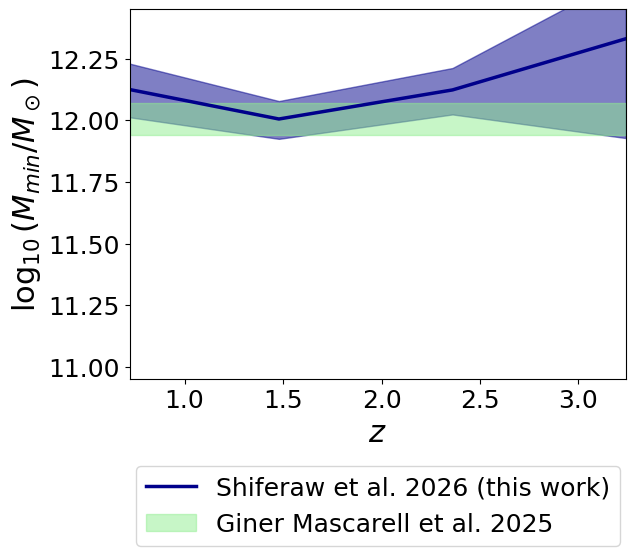

In [164]:
M_min_lo, M_min_hi = np.array(err['log10(M_min)'])[:,0], np.array(err['log10(M_min)'])[:,1]
plt.plot(zbin, M_min, color = 'darkblue', linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)')
plt.fill_between(zbin, M_min_lo, M_min_hi, alpha = 0.5, color = 'darkblue')
# plt.plot(zbin, M_min_array, label = 'Giner Mascarell et al. 2025', color = 'lightgreen', linewidth = 2.5, linestyle = '--')
plt.fill_between(zbin, [11.94]*len(zbin), [12.07]*len(zbin), alpha = 0.5, label = 'Giner Mascarell et al. 2025', color = 'lightgreen')
plt.ylabel('$\log_{10}(M_{min}/M_\odot)$')
plt.xlabel('$z$')
plt.legend(bbox_to_anchor = (0.5, -0.2), loc='upper center')
plt.xlim(zbin[0], zbin[-1])
plt.ylim(10.95,12.45)
plt.show()

In [165]:
f_duty_giner = [0.001986832927349008, 0.001968631474455283, 0.002978657298062041, 0.001968631474455283]

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_244870/546912778.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log_{10}(f_{duty})$')


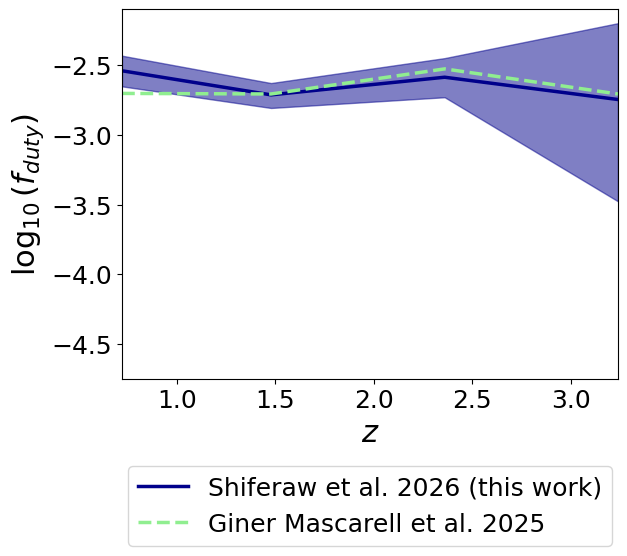

In [166]:
f_duty_lo, f_duty_hi = np.array(err['log10(f_duty)'])[:,0], np.array(err['log10(f_duty)'])[:,1]
plt.plot(zbin, f_duty, color = 'darkblue', linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)')
plt.fill_between(zbin, f_duty_lo, f_duty_hi, alpha = 0.5, color = 'darkblue')
# plt.fill_between(zbin, np.log10(np.array(f_duty_giner)+fduty_err_hi), np.log10(np.array(f_duty_giner)-fduty_err_lo), alpha = 0.5, color = 'lightgreen')
plt.plot(zbin, np.log10(f_duty_giner), label = 'Giner Mascarell et al. 2025', color = 'lightgreen', linewidth = 2.5, linestyle = '--')
plt.ylabel('$\log_{10}(f_{duty})$')
plt.xlabel('$z$')
plt.legend(bbox_to_anchor = (0.5, -0.2), loc='upper center')
plt.xlim(zbin[0], zbin[-1])
plt.ylim(-4.75,-2.1)
plt.show()

In [167]:
b_eff_cf20 = np.load('../results/b_eff_cf20_planck18.npy')

## Calculate 16th and 84th percentile of derived parameters

In [168]:
# for j in z_array:
# equal_weight_samples = dyfunc.resample_equal(samples, weights)
# ind = np.random.choice(range(len(equal_weight_samples)), size = 1000, replace = False)
# f_duty_samples, M_min_samples = equal_weight_samples[ind].T
cf_2h_samples, b_q_samples=[], []
for i in range(len(ind)):
    n_m=np.ones(np.shape(bins))*10**f_duty_samples[j][i]
    cf_2h_sample, b_q_sample = cf_2h(np.logspace(M_min_samples[j][i],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                            recenter = False)
    cf_2h_samples.append(cf_2h_sample)
    b_q_samples.append(b_q_sample)
cf_2h_16, cf_2h_50, cf_2h_84 = np.percentile(cf_2h_samples, [16, 50, 84], axis=0)
b_q_16, b_q_50, b_q_84 = np.percentile(b_q_samples, [16, 50, 84])

In [169]:
n_m=np.ones(np.shape(bins))*10**f_duty[j]
cf_2h_zbin, b_q = cf_2h(np.logspace(M_min[j],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                            recenter = False)
cf_2h_50-cf_2h_zbin

array([-7.67319315e-02, -3.84445782e-02, -2.30164661e-02, -1.51056361e-02,
       -1.04998441e-02, -7.59563470e-03, -5.66025342e-03, -4.31522822e-03,
       -3.35072336e-03, -2.64193561e-03, -2.10970278e-03, -1.70314004e-03,
       -1.38776701e-03, -1.13986363e-03, -9.42409836e-04, -7.83401979e-04,
       -6.54145378e-04, -5.48341201e-04, -4.61184132e-04, -3.88895491e-04,
       -3.29062786e-04, -2.78866074e-04, -2.36976575e-04, -2.01334094e-04,
       -1.71558127e-04, -1.45554398e-04, -1.23317700e-04, -1.03695298e-04,
       -8.62100134e-05, -7.08444430e-05, -5.75983335e-05, -4.66516198e-05,
       -3.91521929e-05, -3.68435623e-05, -4.07352681e-05, -5.19833070e-05,
       -6.75770383e-05, -8.29530110e-05, -9.25726348e-05, -9.34114601e-05,
       -8.58392212e-05, -7.25611814e-05, -5.68187082e-05, -4.11731793e-05,
       -2.71582947e-05, -1.54294626e-05, -6.06194517e-06,  1.16498964e-06,
        6.57761306e-06,  1.05199892e-05,  1.33143941e-05,  1.52319097e-05,
        1.64828302e-05,  

In [170]:
cf_2h_zbin_lo, b_q_lo = cf_2h(np.logspace(M_min_lo[j],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                            recenter = False)
cf_2h_zbin_hi, b_q_hi = cf_2h(np.logspace(M_min_hi[j],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                        recenter = False)

In [171]:
cf_2h_zbin_lo-cf_2h_16, cf_2h_zbin_hi-cf_2h_84

(array([2.78644663e-02, 1.39607805e-02, 8.35820932e-03, 5.48546714e-03,
        3.81291786e-03, 2.75828202e-03, 2.05546684e-03, 1.56703381e-03,
        1.21678311e-03, 9.59393624e-04, 7.66118368e-04, 6.18479002e-04,
        5.03954303e-04, 4.13930565e-04, 3.42227110e-04, 2.84484929e-04,
        2.37546631e-04, 1.99124858e-04, 1.67474602e-04, 1.41223674e-04,
        1.19496000e-04, 1.01267545e-04, 8.60557746e-05, 7.31125488e-05,
        6.22996913e-05, 5.28566862e-05, 4.47816420e-05, 3.76559547e-05,
        3.13063410e-05, 2.57264812e-05, 2.09162834e-05, 1.69410891e-05,
        1.42177440e-05, 1.33793869e-05, 1.47926226e-05, 1.88772403e-05,
        2.45399545e-05, 3.01235918e-05, 3.36168661e-05, 3.39214774e-05,
        3.11716914e-05, 2.63498983e-05, 2.06331699e-05, 1.49516459e-05,
        9.86227471e-06, 5.60306163e-06, 2.20133735e-06, 4.43215926e-05,
        2.50242815e-04, 4.00229034e-04, 5.06541118e-04, 5.79492279e-04,
        6.27083079e-04, 6.55498903e-04, 6.69598135e-04, 6.730766

<>:73: SyntaxWarning: invalid escape sequence '\l'
<>:73: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_244870/2853167586.py:73: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))


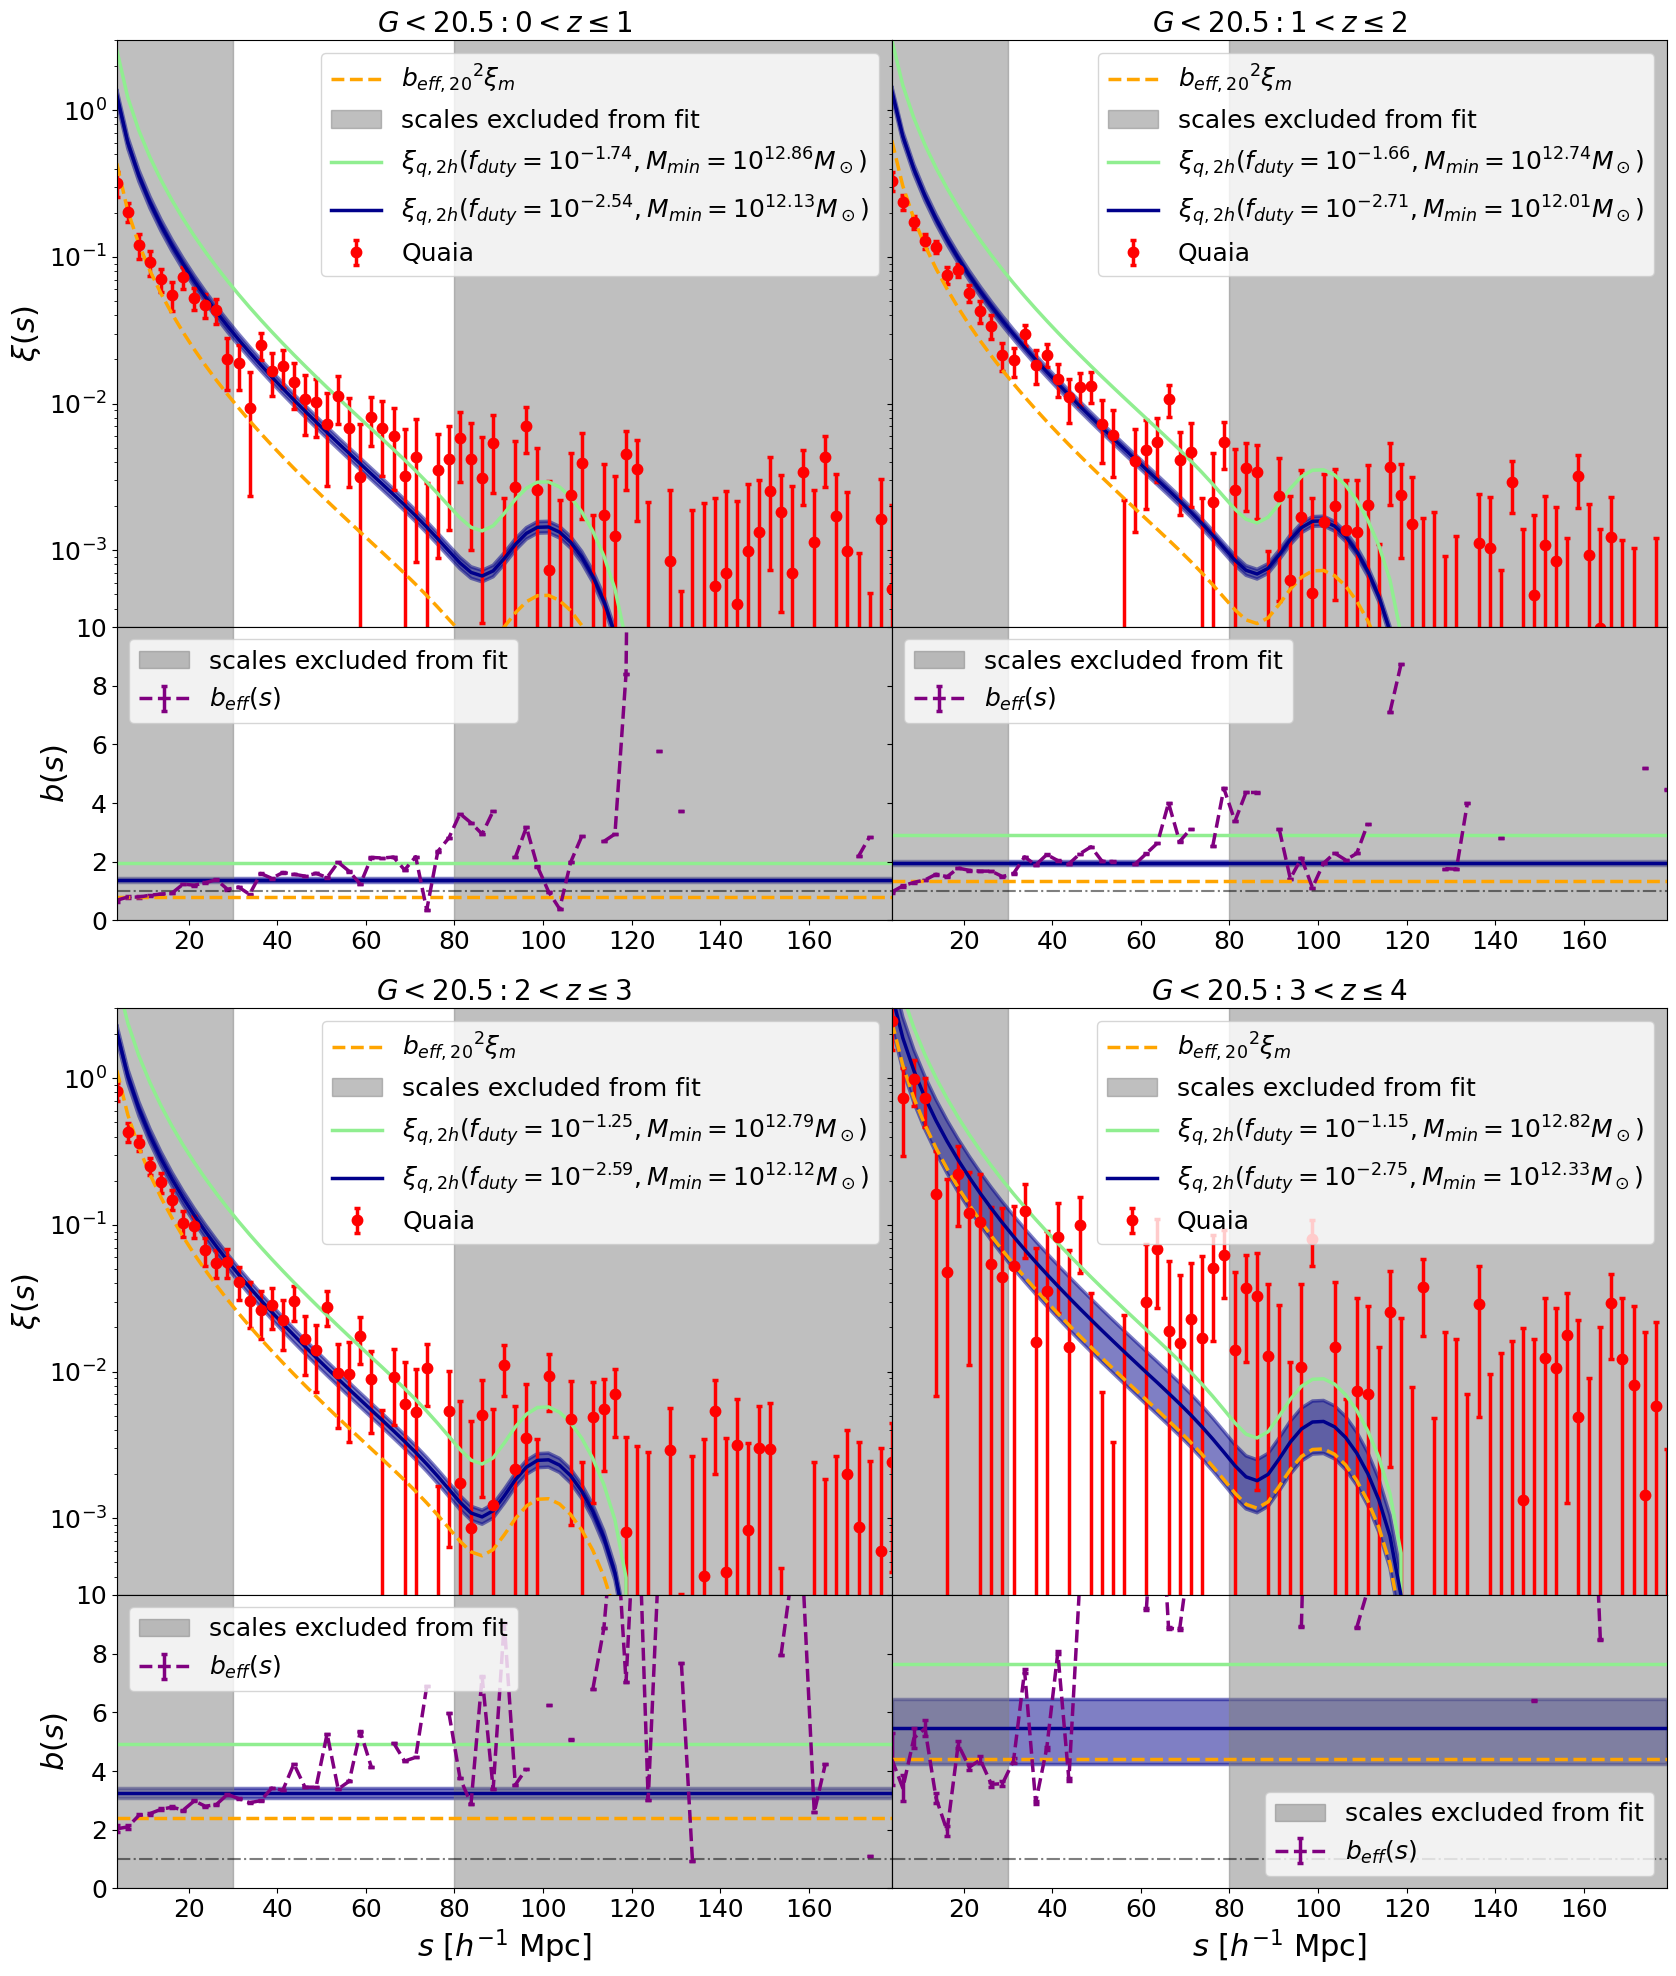

In [172]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.15, 1, 0.5], hspace = 0, wspace = 0)

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
    
    # C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25_{}.npy'.format(G_hi, rmin, rmax, nbins, j, cosmo)) # [np.ix_([False]+[True]*20+[False], [False]+[True]*20+[False])] # very good
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good
    
    ax1.errorbar(quaia.recenter(rbins_chi2), cf_chi2[j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = 'red',
                yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    ax1.plot(quaia.recenter(rbins_chi2), b_eff_cf20[j]**2*cf_matter_chi2[j], linewidth = 2.5,
             label = r'${b_{eff, 20}}^2\xi_m$', color = 'orange', linestyle = '--')
    ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                      alpha = 0.5, label = 'scales excluded from fit')
    ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                      alpha = 0.5)

    # old fit
    cf_2h_zbin, b_q = cf_2h(bins_M_min[j], n_m_array[j], a_zbin[j], cosmo_planck18, cf_matter_chi2[j], recenter = False)
    ax1.plot(quaia.recenter(rbins_chi2), cf_2h_zbin, linewidth = 2.5, 
             label = r'$\xi_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(np.log10(fduty[j]), M_min_array[j]),
             color = 'lightgreen')
    ax2.axhline(b_q, linewidth = 2.5, color = 'lightgreen')

    # plot new fit
    n_m=np.ones(np.shape(bins))*f_duty[j]
    cf_2h_zbin, b_q = cf_2h(np.logspace(M_min[j],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                            recenter = False)
    ax1.plot(quaia.recenter(rbins_chi2), cf_2h_zbin, linewidth = 2.5,
             label = r'$\xi_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[j], M_min[j]), 
             color = 'darkblue')
    
    cf_2h_samples, b_q_samples=[], []
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*10**f_duty_samples[j][i]
        cf_2h_sample, b_q_sample = cf_2h(np.logspace(M_min_samples[j][i],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                                recenter = False)
        cf_2h_samples.append(cf_2h_sample)
        b_q_samples.append(b_q_sample)
    cf_2h_16, cf_2h_50, cf_2h_84 = np.percentile(cf_2h_samples, [16, 50, 84], axis=0)
    b_q_16, b_q_50, b_q_84 = np.percentile(b_q_samples, [16, 50, 84])

    ax1.fill_between(quaia.recenter(rbins_chi2), cf_2h_16, cf_2h_84, linewidth = 2.5, alpha = 0.5,
             color = 'darkblue')
    ax2.axhline(b_q, linewidth = 2.5, color = 'darkblue')
    ax2.fill_between(quaia.recenter(rbins_chi2), [b_q_16]*nbins, [b_q_84]*nbins, linewidth = 2.5, color = 'darkblue', alpha = 0.5)

    # ax1.plot(quaia.recenter(rbins_chi2), cf_2h_50, linewidth = 2.5,
    #          label = r'$\xi_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[j], M_min[j]),
    #          color = 'darkblue')
    # cf_2h_zbin_lo, b_q_lo = cf_2h(np.logspace(M_min_lo[j],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
    #                         recenter = False)
    # cf_2h_zbin_hi, b_q_hi = cf_2h(np.logspace(M_min_hi[j],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
    #                         recenter = False)
    # ax1.fill_between(quaia.recenter(rbins_chi2), cf_2h_zbin_lo, cf_2h_zbin_hi, linewidth = 2.5, alpha = 0.5,
    #          color = 'darkblue')
    # ax2.axhline(b_q_50, linewidth = 2.5, color = 'darkblue')
    # ax2.fill_between(quaia.recenter(rbins_chi2), [b_q_lo]*nbins, [b_q_hi]*nbins, linewidth = 2.5, color = 'darkblue', alpha = 0.5)
    
    ax2.errorbar(quaia.recenter(rbins_chi2), b_cf_chi2[j], linewidth = 2.5, linestyle = '--', markeredgewidth = 2.5, capsize = 2.5,
                 color = 'purple', yerr = np.sqrt(np.diag(C)), label = '$b_{eff}(s)$')
    ax2.axhline(b_eff_cf20[j], linewidth = 2.5, color = 'orange', linestyle = '--')
    ax2.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                      alpha = 0.5, label = 'scales excluded from fit')
    ax2.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                      alpha = 0.5)
    
    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 3)
    ax1.legend()

    ax2.axhline(1, linestyle = '-.', color = 'black', alpha = 0.5)
    ax2.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax2.set_ylim(0, 10)
    ax2.legend()
    
    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        ax2.set_ylabel(r'$b(s)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if k != 0:
        ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # 
            
    if j % 2 != 0:
        k+=4

plt.show()

<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:45: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_244870/1626812543.py:45: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))


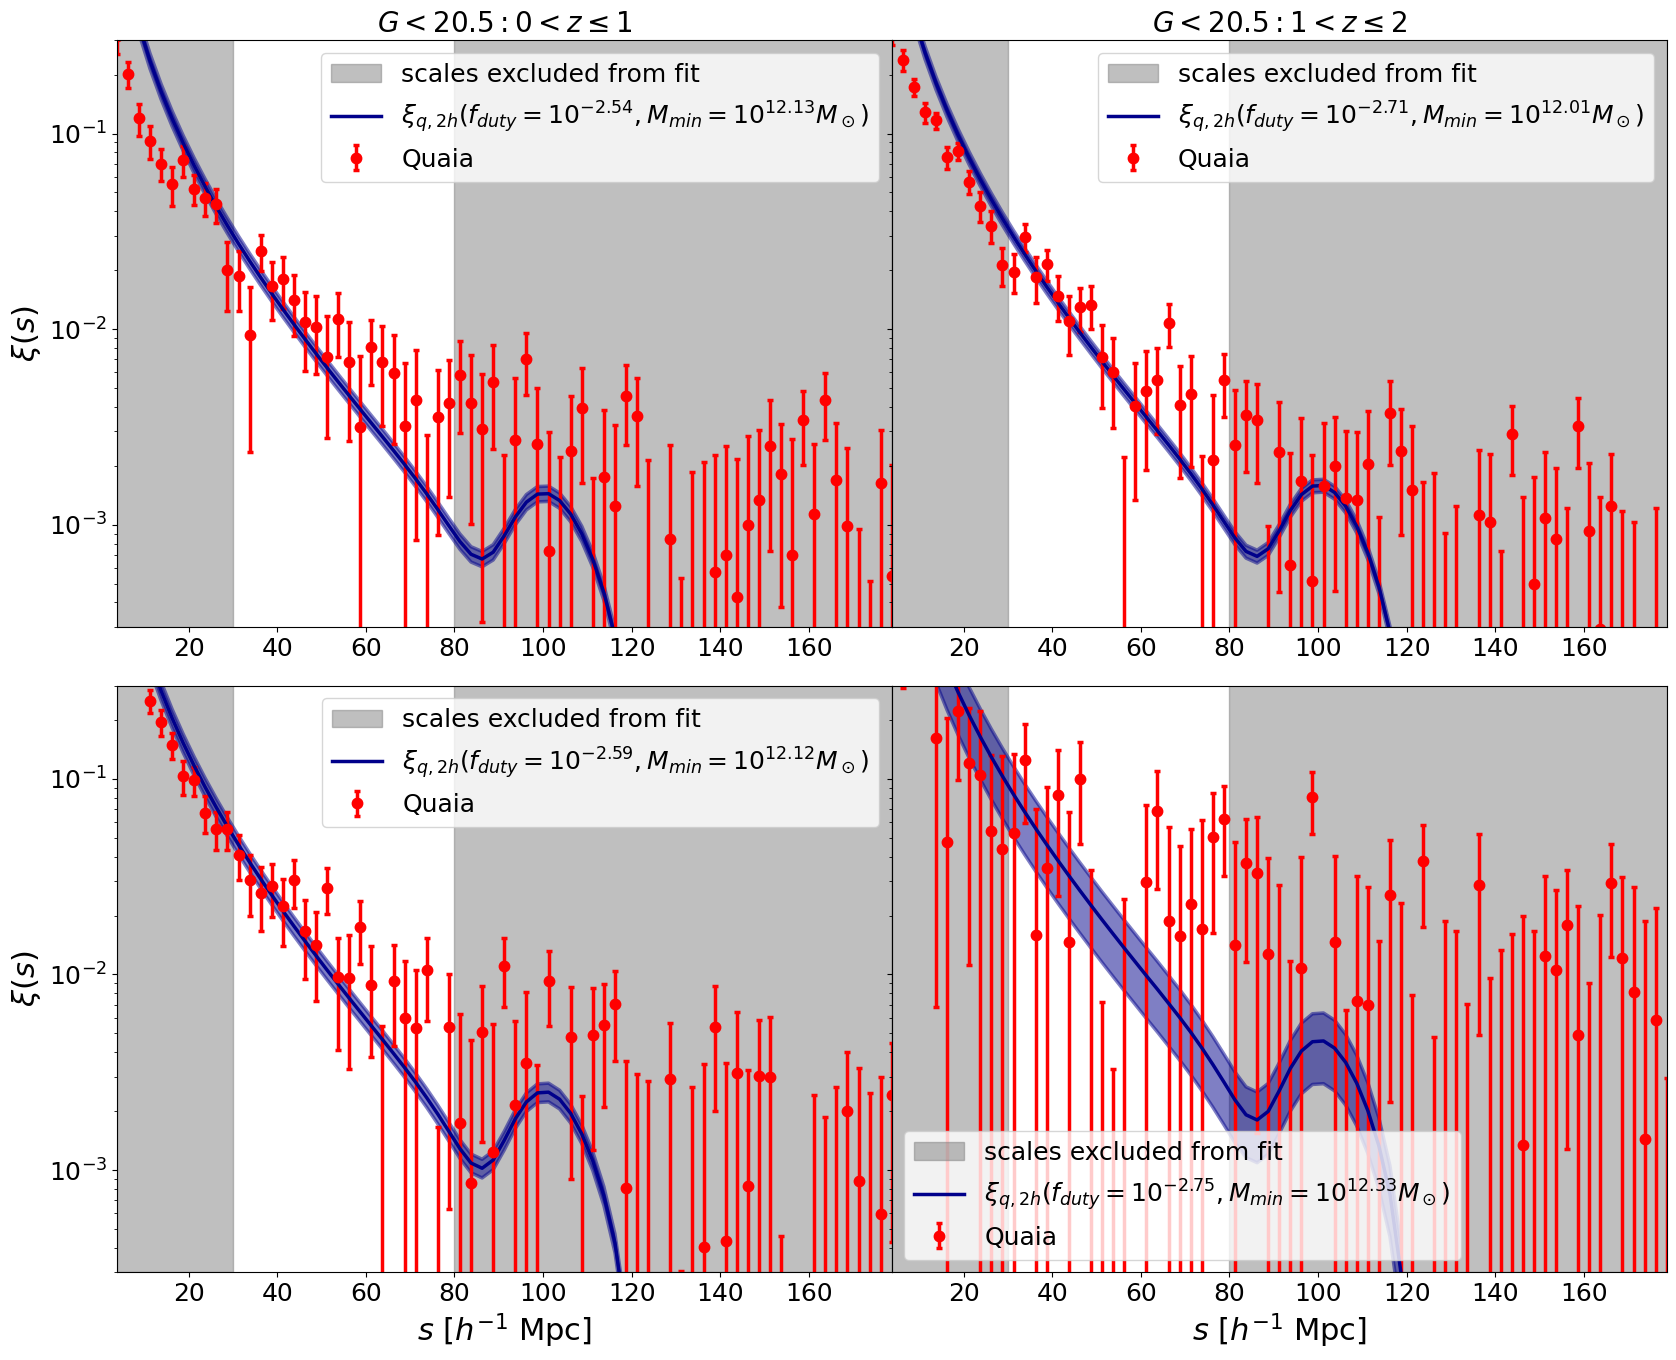

In [173]:
# remove bottom panel and just print bq somewhere
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, hspace = 0.1, wspace = 0)

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j])
    
    # C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25_{}.npy'.format(G_hi, rmin, rmax, nbins, j, cosmo)) # [np.ix_([False]+[True]*20+[False], [False]+[True]*20+[False])] # very good
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good
           
    ax1.errorbar(quaia.recenter(rbins_chi2), cf_chi2[j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = 'red',
                yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                      alpha = 0.5, label = 'scales excluded from fit')
    ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                      alpha = 0.5)

    # plot new fit
    n_m=np.ones(np.shape(bins))*f_duty[j]
    cf_2h_zbin, b_q = cf_2h(np.logspace(M_min[j],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                            recenter = False)
    ax1.plot(quaia.recenter(rbins_chi2), cf_2h_zbin, linewidth = 2.5,
             label = r'$\xi_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[j], M_min[j]), 
             color = 'darkblue')

    cf_2h_samples = []
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*f_duty_samples[j][i]
        cf_2h_sample, _ = cf_2h(np.logspace(M_min_samples[j][i],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                                recenter = False)
        cf_2h_samples.append(cf_2h_sample)
    cf_2h_16, cf_2h_50, cf_2h_84 = np.percentile(cf_2h_samples, [16, 50, 84], axis=0)
    ax1.fill_between(quaia.recenter(rbins_chi2), cf_2h_16, cf_2h_84, linewidth = 2.5, alpha = 0.5,
             color = 'darkblue')    
    # cf_2h_zbin_lo, b_q_lo = cf_2h(np.logspace(M_min_lo[j],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
    #                         recenter = False)
    # cf_2h_zbin_hi, b_q_hi = cf_2h(np.logspace(M_min_hi[j],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
    #                         recenter = False)
    # ax1.fill_between(quaia.recenter(rbins_chi2), cf_2h_zbin_lo, cf_2h_zbin_hi, linewidth = 2.5, alpha = 0.5,
    #          color = 'darkblue')

    if j % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax1.set_ylim(3e-4, 3e-1)
    ax1.legend()
    
    if j % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        # ax2.set_ylabel(r'$b(s)$')

    else:
        ax1.set_yticklabels([])
        # ax2.set_yticklabels([])

    if j > 1:
        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # 
            
    if j % 2 != 0:
        k+=2

plt.show()

<>:43: SyntaxWarning: invalid escape sequence '\l'
<>:62: SyntaxWarning: invalid escape sequence '\D'
<>:43: SyntaxWarning: invalid escape sequence '\l'
<>:62: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_244870/846967146.py:43: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
/tmp/ipykernel_244870/846967146.py:62: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(M_{min}/M_\odot)$')


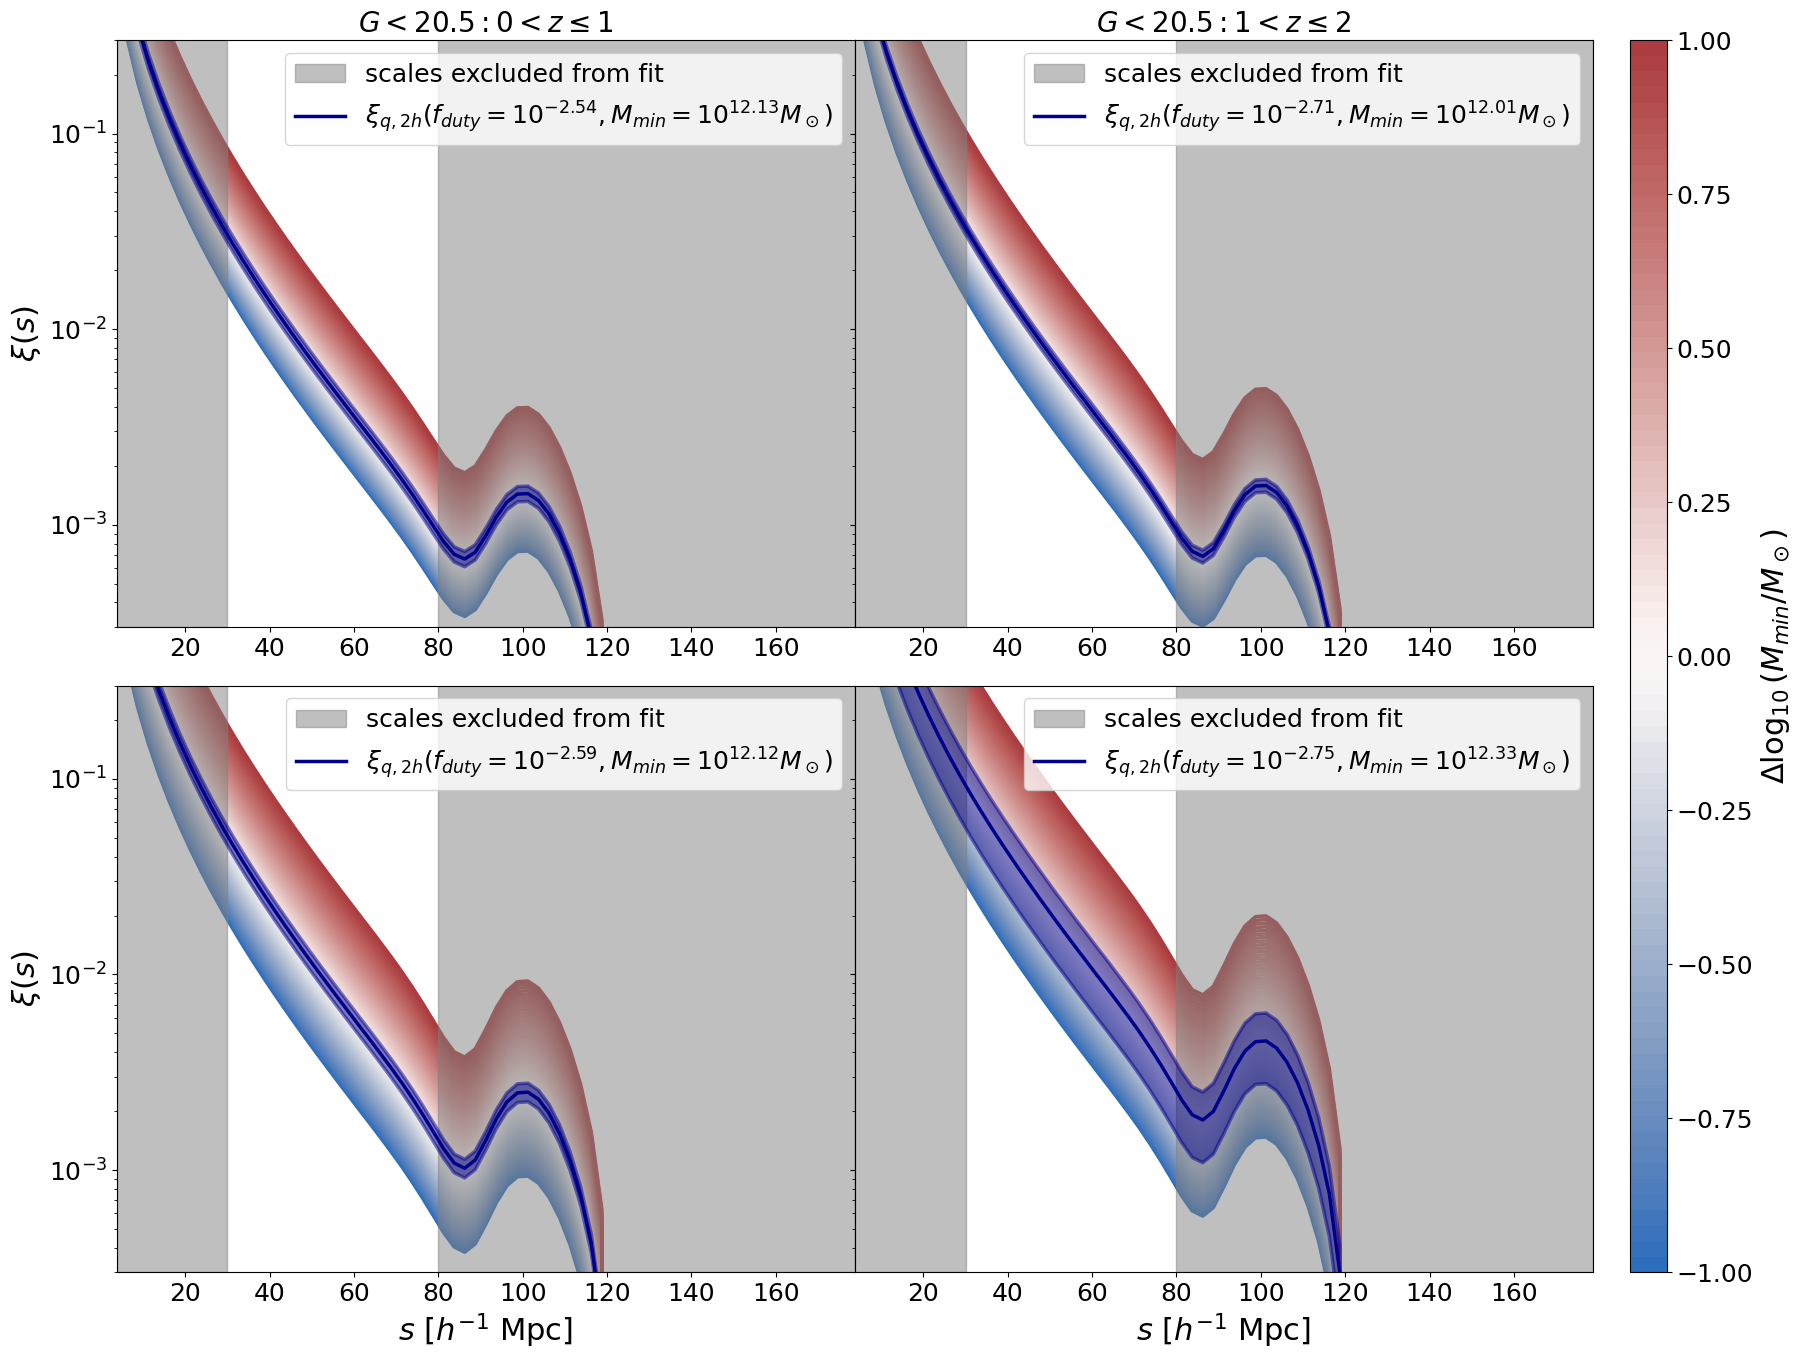

In [185]:
# remove bottom panel and just print bq somewhere
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 4, hspace = 0.1, wspace = 0, width_ratios = [1,1,0.05,0.05])

l = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+l])
    
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good
           
    # ax1.errorbar(quaia.recenter(rbins_chi2), cf_chi2[j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = 'red',
    #             yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                      alpha = 0.5, label = 'scales excluded from fit')
    ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                      alpha = 0.5)

    # plot new fit
    n_m=np.ones(np.shape(bins))*f_duty[j]
    cf_2h_zbin, b_q = cf_2h(np.logspace(M_min[j],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                            recenter = False)
    ax1.plot(quaia.recenter(rbins_chi2), cf_2h_zbin, linewidth = 2.5,
             label = r'$\xi_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[j], M_min[j]), 
             color = 'darkblue')

    for k in range(len(bins)):
        cf_2h_sample, _ = cf_2h(np.logspace(M_min[j]-1+k/int(len(bins)/2), M_max, 79), n_m, a_zbin[j], 
                 cosmo_planck18, cf_matter_chi2[j], recenter = False)
        ax1.plot(quaia.recenter(rbins_chi2), cf_2h_sample, linewidth = 2.5, color = cmap_M_min[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))
        
    cf_2h_samples = []
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*f_duty_samples[j][i]
        cf_2h_sample, _ = cf_2h(np.logspace(M_min_samples[j][i],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                                recenter = False)
        cf_2h_samples.append(cf_2h_sample)
    cf_2h_16, cf_2h_50, cf_2h_84 = np.percentile(cf_2h_samples, [16, 50, 84], axis=0)
    ax1.fill_between(quaia.recenter(rbins_chi2), cf_2h_16, cf_2h_84, linewidth = 2.5, alpha = 0.5,
             color = 'darkblue')    
    
    if j % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax1.set_ylim(3e-4, 3e-1)
    ax1.legend()
    
    if j % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')

    else:
        ax1.set_yticklabels([])

    if j > 1:
        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # 
            
    if j == 1:
        l+=2

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

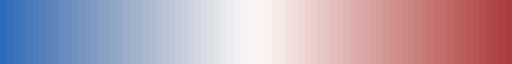

In [175]:
cmap_M_min = sns.color_palette("vlag", n_colors = len(bins))
palette_M_min = matplotlib.colors.ListedColormap(cmap_M_min)
palette_M_min

In [176]:
b_q_percentile = []
for j in z_array:
    b_q_samples=[]
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*10**f_duty_samples[j][i]
        b_q_samples.append(cf_2h(np.logspace(M_min_samples[j][i],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                                recenter = False)[1])
    b_q_percentile.append(np.percentile(b_q_samples, [16, 84]))
b_q_lo, b_q_hi = np.array(b_q_percentile).T

<>:56: SyntaxWarning: invalid escape sequence '\D'
<>:56: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_244870/2217826274.py:56: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(M_{min}/M_\odot)$')


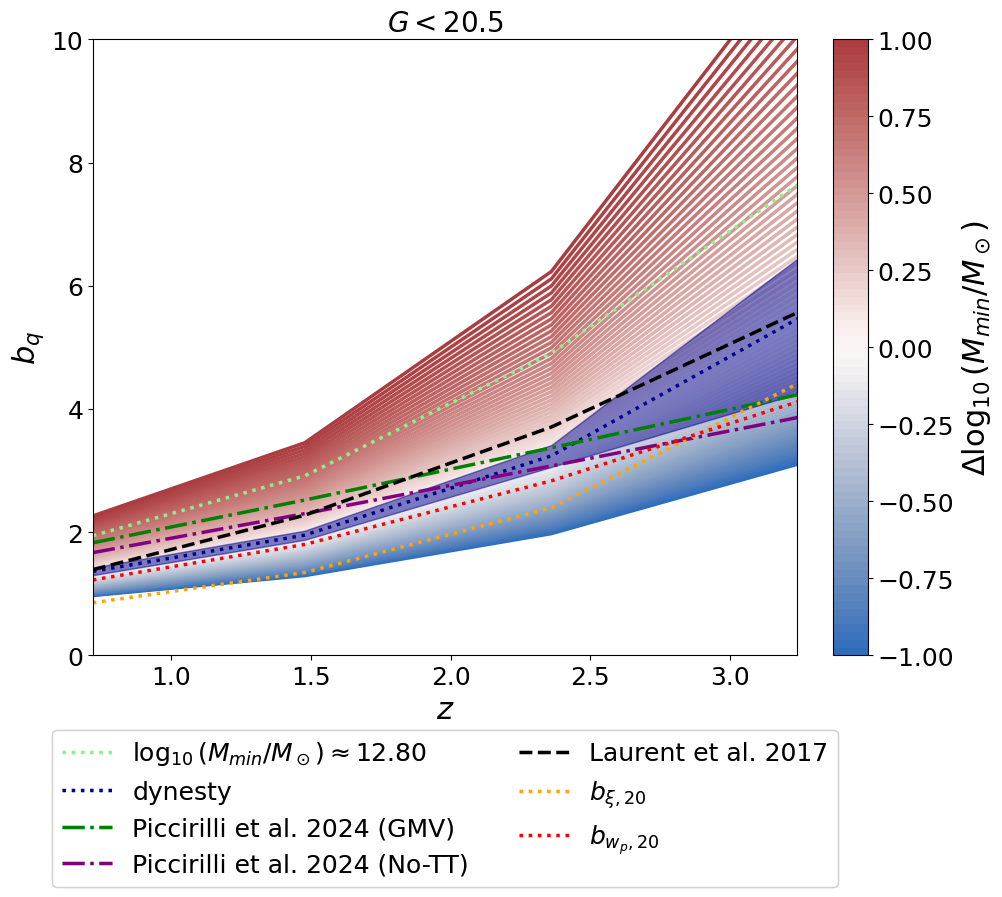

In [177]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
    
b_q = [cf_2h(bins_M_min[j], n_m_array[j], a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
             recenter = False)[1] for j in z_array]
ax1.plot(zbin, b_q, linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

b_q = [cf_2h(np.logspace(M_min[j], M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a_zbin[j], cosmo_planck18, 
             cf_matter_chi2[j], recenter = False)[1] for j in z_array]
ax1.plot(zbin, b_q, linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

# b_q_lo = [cf_2h(np.logspace(M_min_lo[j], M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a_zbin[j], cosmo_planck18, 
#              cf_chi2[j], recenter = False)[1] for j in z_array]
# b_q_hi = [cf_2h(np.logspace(M_min_hi[j], M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a_zbin[j], cosmo_planck18, 
#              cf_chi2[j], recenter = False)[1] for j in z_array]
ax1.fill_between(zbin, b_q_lo, b_q_hi, alpha = 0.5, color = 'darkblue') # color = cmaps[i][j], alpha = (l+1)/len(bins))

for k in range(len(bins)):
    b_q = [cf_2h(np.logspace(M_min[j]-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*f_duty[j], a_zbin[j], 
                 cosmo_planck18, cf_matter_chi2[j], recenter = False)[1] for j in z_array]
    ax1.plot(zbin, b_q, linewidth = 2.5, color = cmap_M_min[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.plot(zbin, b_quaia(1.26, a_zbin), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (GMV)', color = 'green') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(zbin, b_quaia(1.15, a_zbin), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (No-TT)', color = 'purple') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(zbin, b_eboss(zbin), linestyle = '--', linewidth = 2.5, label = 'Laurent et al. 2017', 
         color = 'black') # eq 3.6 in https://arxiv.org/abs/2402.05761

ax1.plot(zbin, b_cf20, linestyle = ':', linewidth = 2.5, label = r'$b_{\xi, 20}$', color = 'orange') 
ax1.plot(zbin, b_wp20, linestyle = ':', linewidth = 2.5, label = '$b_{w_p, 20}$', color = 'red') 

ax1.set_title('$G<{}$'.format(G_hi))

ax1.set_xlabel('$z$')
ax1.set_ylim(0, 10)
ax1.set_xlim(zbin[0], zbin[-1])
ax1.set_ylabel(r'$b_q$')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'green', linestyle = '-.', linewidth = 2.5), 
                Line2D([0], [0], color = 'purple', linestyle = '-.', linewidth = 2.5),
                Line2D([0], [0], color = 'black', linestyle = '--', linewidth = 2.5), 
                Line2D([0], [0], color = 'orange', linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = 'red', linestyle = ':', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(12.8), 
                                          'dynesty', 'Piccirilli et al. 2024 (GMV)', 'Piccirilli et al. 2024 (No-TT)', 
                                          'Laurent et al. 2017', r'$b_{\xi, 20}$', '$b_{w_p, 20}$'], ncol = 2, bbox_to_anchor = (0.5, -0.1), 
                           loc='upper center')
fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [178]:
M_h_percentile = []
for j in z_array:
    M_h_samples=[]
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*10**f_duty_samples[j][i]
        M_h_samples.append(M(np.logspace(M_min_samples[j][i], M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, 
         recenter = False)[0])
    M_h_percentile.append(np.percentile(M_h_samples, [16, 84]))
M_h_lo, M_h_hi = np.array(M_h_percentile).T

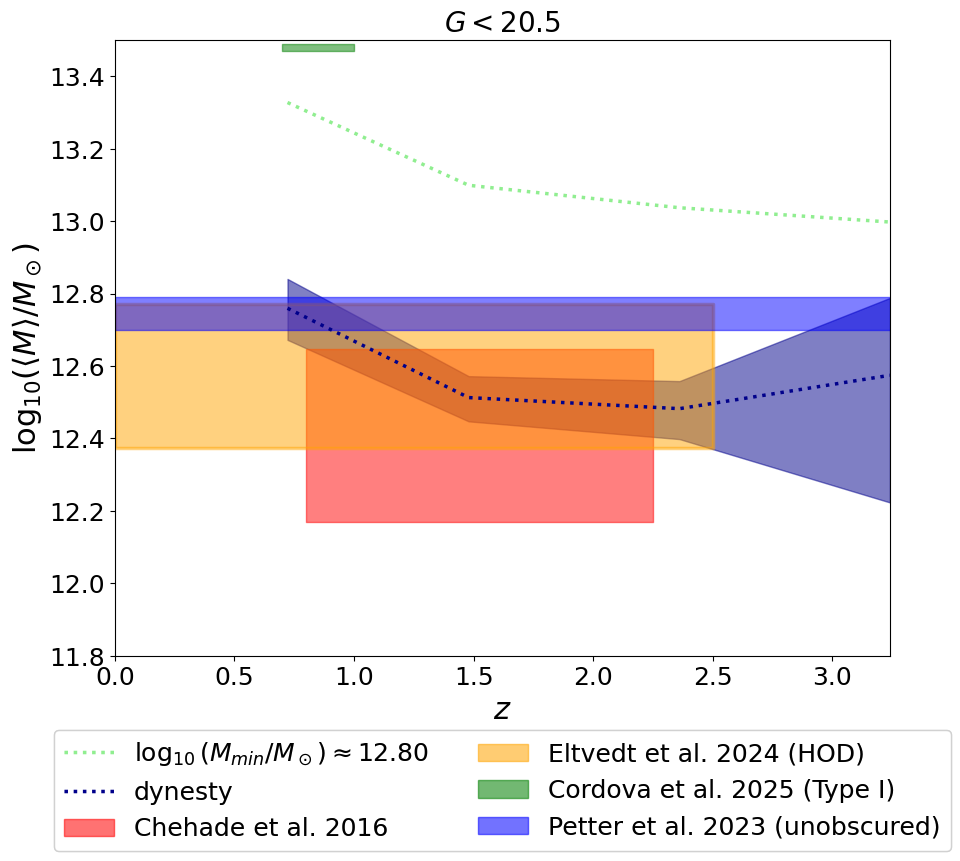

In [179]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 1, wspace = 0)
ax1 = fig.add_subplot(gs[0])
    
M_h = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
# plt.fill_between(zbin, [11.94]*len(zbin), [12.07]*len(zbin), alpha = 0.5, label = 'Giner Mascarell et al. 2025', color = 'lightgreen')

M_h = [M(np.logspace(M_min[j], M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a = a_zbin[j], cosmo = cosmo_planck18, 
         recenter = False)[0] for j in z_array]
ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

# M_h_lo = [M(np.logspace(M_min_lo[j], M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a = a_zbin[j], cosmo = cosmo_planck18, 
#          recenter = False)[0] for j in z_array]
# M_h_hi = [M(np.logspace(M_min_hi[j], M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a = a_zbin[j], cosmo = cosmo_planck18, 
#          recenter = False)[0] for j in z_array]
ax1.fill_between(zbin, np.log10(M_h_lo), np.log10(M_h_hi), alpha = 0.5, color = 'darkblue') # color = cmaps[i][j], alpha = (l+1)/len(bins))

z = np.linspace(0.8, 2.25)
ax1.fill_between(z, [np.log10(1e12/Planck18.h)]*len(z), [np.log10(3e12/Planck18.h)]*len(z), alpha = 0.5, 
                 label = 'Chehade et al. 2016', color = 'red')
ax1.set_title('$G<{}$'.format(G_hi))
ax1.fill_between(np.linspace(0, 2.5), [np.log10(1.6e12/Planck18.h)]*len(z), [np.log10(4e12/Planck18.h)]*len(z), linewidth = 2.5, 
                 label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
ax1.fill_between(np.linspace(0.7, 1), [13.47]*len(z), [13.49]*len(z), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

# check redshift range and check cordova type i was right to include because conflicts with this
ax1.fill_between(np.linspace(0, 3.5), [np.log10(10**12.53/Planck18.h)]*len(z), [np.log10(10**12.62/Planck18.h)]*len(z), alpha = 0.5, 
                 label = 'Petter et al. 2023 (unobscured)', color = 'blue')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5), 
                # mpatches.Patch(color='lightgreen', alpha = 0.5), 
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [#'Giner Mascarell et al. 2025', 
                                          r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(12.8), 
                                          'dynesty', 'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 2, bbox_to_anchor = (0.5, -0.1), loc='upper center')
fig.add_artist(second_legend)

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
ax1.set_xlim(0, zbin[-1])
ax1.set_ylim(11.8, 13.5)

plt.show()

<>:46: SyntaxWarning: invalid escape sequence '\D'
<>:46: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_244870/1482196861.py:46: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(M_{min}/M_\odot)$')


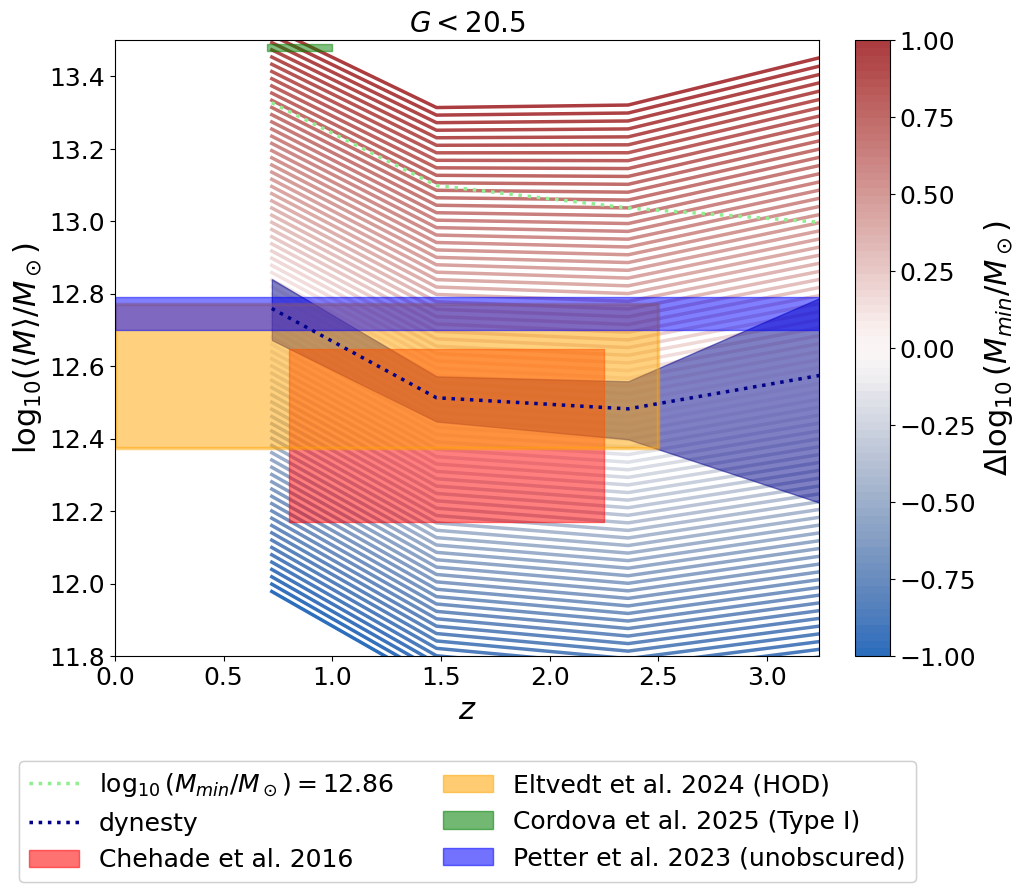

In [180]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])

for k in range(len(bins)):
    
    M_h = [M(np.logspace(M_min[j]-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
    ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, 
             label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:{:.2f} M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[k])),
             color = cmap_M_min[k], zorder = 0) #, alpha = (1+k)/len(bins))
    
M_h = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

M_h = [M(np.logspace(M_min[j], M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a = a_zbin[j], cosmo = cosmo_planck18, 
         recenter = False)[0] for j in range(len(z_array))]
ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.fill_between(zbin, np.log10(M_h_lo), np.log10(M_h_hi), alpha = 0.5, color = 'darkblue') # color = cmaps[i][j], alpha = (l+1)/len(bins))

z = np.linspace(0.8, 2.25)
ax1.fill_between(z, [np.log10(1e12/Planck18.h)]*len(z), [np.log10(3e12/Planck18.h)]*len(z), alpha = 0.5, 
                 label = 'Chehade et al. 2016', color = 'red')
ax1.set_title('$G<{}$'.format(G_hi))
ax1.fill_between(np.linspace(0, 2.5), [np.log10(1.6e12/Planck18.h)]*len(z), [np.log10(4e12/Planck18.h)]*len(z), linewidth = 2.5, 
                 label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
ax1.fill_between(np.linspace(0.7, 1), [13.47]*len(z), [13.49]*len(z), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

# check redshift range and check cordova type i was right to include because conflicts with this
ax1.fill_between(np.linspace(0, 3.5), [np.log10(10**12.53/Planck18.h)]*len(z), [np.log10(10**12.62/Planck18.h)]*len(z), alpha = 0.5, 
                 label = 'Petter et al. 2023 (unobscured)', color = 'blue')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5), Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0]), 'dynesty',
                            'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 2, bbox_to_anchor = (0.5, -0.15), loc='upper center')
fig.add_artist(second_legend)

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
ax1.set_xlim(0, zbin[-1])
ax1.set_ylim(11.8, 13.5)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [181]:
fduty_array = np.logspace(-5,0, 51) #-4

In [182]:
cmap_fduty_k = sns.color_palette("vlag", n_colors = len(fduty_array))

In [183]:
n_q_percentile = []
for j in z_array:
    n_q_samples=[]
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*10**f_duty_samples[j][i]
        n_q_samples.append(M(np.logspace(M_min_samples[j][i], M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, 
         recenter = False)[1])
    n_q_percentile.append(np.percentile(n_q_samples, [16, 84]))
n_q_theory_fit_lo, n_q_theory_fit_hi = np.array(n_q_percentile).T

<>:46: SyntaxWarning: invalid escape sequence '\D'
<>:86: SyntaxWarning: invalid escape sequence '\D'
<>:46: SyntaxWarning: invalid escape sequence '\D'
<>:86: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_244870/2488807320.py:46: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
/tmp/ipykernel_244870/2488807320.py:86: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(f_{duty})$')


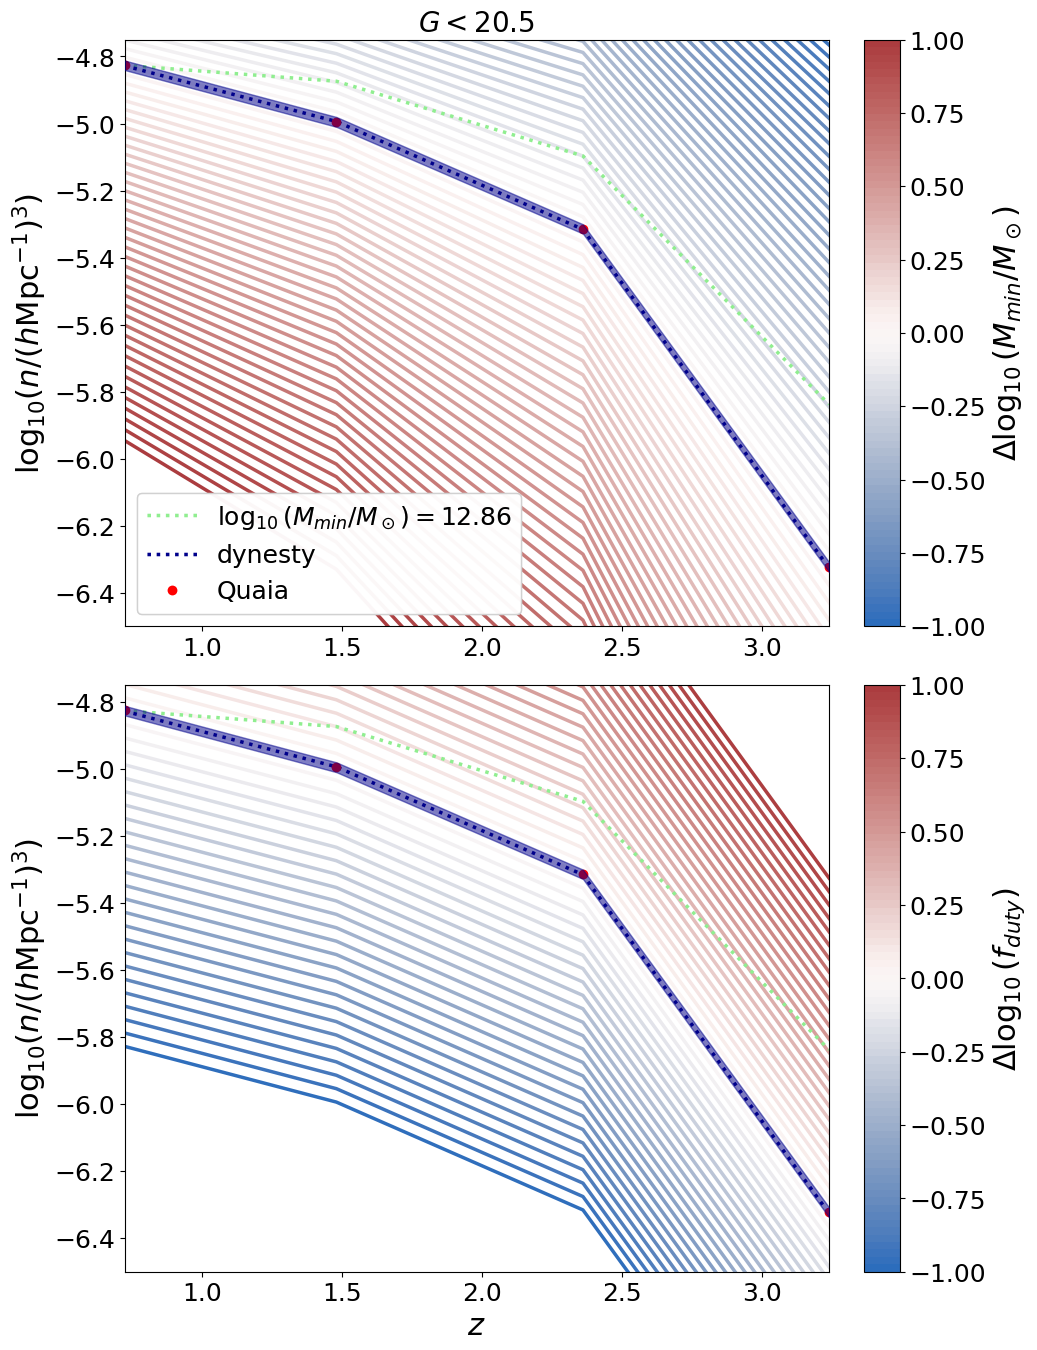

In [184]:
fig = plt.figure(figsize = (10, 16))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(2, 3, width_ratios = [1, 0.05, 0.05], wspace = 0, hspace = 0.1)
ax1 = fig.add_subplot(gs[0])
ylim = -6.5, -4.75

for k in range(len(bins)):
    
    n_q_theory = [M(np.logspace(M_min[j]-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1] for j in z_array]
    ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:[{:.2f}-{:.2f}] M_\odot$'.format(f_duty[0]*100, f_duty[-1]*100, np.log10(bins[0]), 
                                                                                                  np.log10(bins[-1])), color = cmap_M_min[k])
    
n_q_theory, n_q_theory_fit = [], [] #, n_q_theory_fit_lo, n_q_theory_fit_hi = [], [], [], []
for j in z_array:
    
    n_q_theory.append(M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])
    
    n_m=np.ones(np.shape(bins))*10**f_duty[j]
    n_q_theory_fit.append(M(np.logspace(M_min[j], M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])
    # n_q_theory_fit_lo.append(M(np.logspace(M_min_lo[j], M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])
    # n_q_theory_fit_hi.append(M(np.logspace(M_min_hi[j], M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])

ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.plot(zbin, np.log10(n_q_theory_fit), linewidth = 2.5, color = 'darkblue', linestyle = ':', label = r'$\chi^2$ minimization') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.fill_between(zbin, np.log10(n_q_theory_fit_lo), np.log10(n_q_theory_fit_hi), color = 'darkblue', alpha = 0.5, label = r'$\chi^2$ minimization', zorder = 3) # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.errorbar(zbin, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

ax1.set_title('$G<{}$'.format(G_hi))
ax1.set_xlim(zbin[0], zbin[-1])

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5, 
                       label = r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0])),
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5, 
                       label = 'dynesty'), 
                Line2D([0], [0], color = 'red', marker = 'o', linestyle = 'None', linewidth = 2.5, label = 'Quaia')]
second_legend = ax1.legend(handles = custom_lines)
fig.add_artist(second_legend)

# ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
ax1.set_ylim(ylim)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[0,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
# plt.show()

# fig = plt.figure(figsize = (10, 8))
# labels_cf = ['qq', r'$\xi_{2h}$']
# gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[3])
i = 1
l = 38

for k in range(len(fduty_array)):

    n_q_theory=[]
    for j in z_array:
        
        n_m = np.ones(np.shape(bins))*10**(f_duty[j]-1+k/int(len(fduty_array)/2))
        n_q_theory.append(M(np.logspace(M_min[j], M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])
        
    ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             color = cmap_fduty_k[k])
    
n_q_theory = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1] for j in z_array]
ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = 'lightgreen', linestyle = ':', 
         label = r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0])) # color = cmaps[i][j], alpha = (l+1)/len(bins)) np.log10(bins[l])

ax1.plot(zbin, np.log10(n_q_theory_fit), linewidth = 2.5, color = 'darkblue', linestyle = ':', label = r'dynesty') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.fill_between(zbin, np.log10(n_q_theory_fit_lo), np.log10(n_q_theory_fit_hi), color = 'darkblue', alpha = 0.5, zorder = 3) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.errorbar(zbin, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

# ax1.set_title('$G<{}$'.format(G_hi))

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
ax1.set_ylim(ylim)
# ax1.legend()
ax1.set_xlim(zbin[0], zbin[-1])

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[1,-1]), 
                    label = '$\Delta \log_{10}(f_{duty})$')
plt.show()

# Debug covariance
## Check that masking is the same

In [245]:
# Create the bins array
offset = 2.5
delta_max = 1 #64
delta_min = 1 #np.min((np.floor((30-0.15)/offset), delta_max))

rmin = 30-delta_min*offset # 0.1 # start higher # 1.4 # 30
rmax = 80+delta_max*offset # 200
nbins = 20 + int(delta_min+delta_max) #90 #20
rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'linear'
rbins, quaia.recenter(rbins), np.diff(quaia.recenter(rbins))

(array([27.5, 30. , 32.5, 35. , 37.5, 40. , 42.5, 45. , 47.5, 50. , 52.5,
        55. , 57.5, 60. , 62.5, 65. , 67.5, 70. , 72.5, 75. , 77.5, 80. ,
        82.5]),
 array([28.75, 31.25, 33.75, 36.25, 38.75, 41.25, 43.75, 46.25, 48.75,
        51.25, 53.75, 56.25, 58.75, 61.25, 63.75, 66.25, 68.75, 71.25,
        73.75, 76.25, 78.75, 81.25]),
 array([2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5,
        2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5]))

In [178]:
j = 0
C_unmasked = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25_{}.npy'.format(G_hi, rmin, rmax, nbins, j, cosmo))
C_masked = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25_{}.npy'.format(G_hi, 30, 80, 20, j, cosmo))

In [179]:
r = quaia.recenter(rbins) 
rpmask = (r >= 30) & (r  <= 80)
ix_grid = np.ix_(rpmask, rpmask)

In [180]:
np.max(C_unmasked[ix_grid]-C_masked)

1.2705494208814505e-21

(-1.0, 1.0)


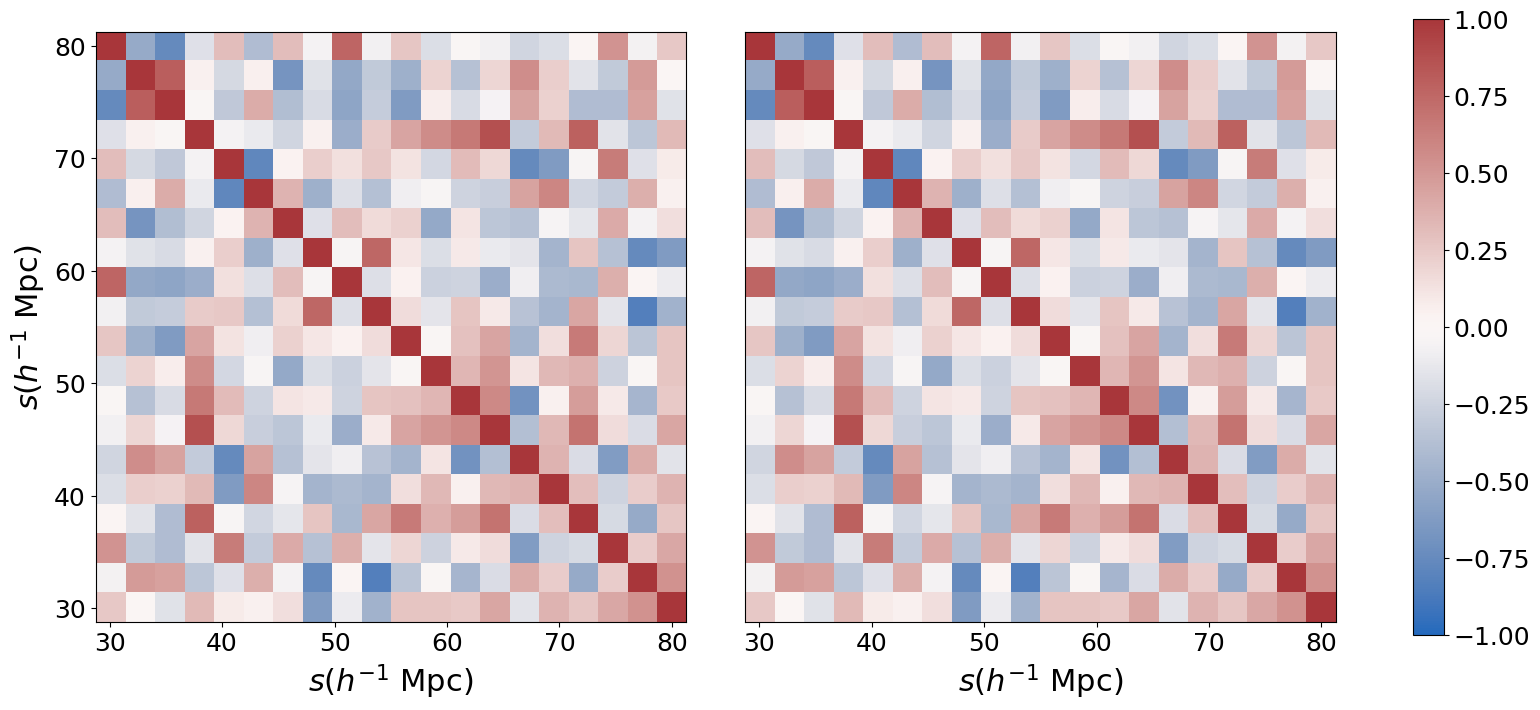

In [181]:
cmap = sns.color_palette("vlag", as_cmap=True)

# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0.1, hspace = 0.1)
# axes = []
# for i in range(len(zbin_array)-1):
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_N{}_{}.npy'.format(G_hi, rmin, rmax, nbins, zbin_array[i], zbin_array[i+1], N, cosmo))
matrix = np.corrcoef(C_unmasked[ix_grid])
image = ax1.imshow(matrix, cmap = cmap, extent = [r[0], r[-1], r[0], r[-1]], vmin = -1, vmax = 1)
matrix = np.corrcoef(C_masked)
image = ax2.imshow(matrix, cmap = cmap, extent = [r[0], r[-1], r[0], r[-1]], vmin = -1, vmax = 1)
print(image.get_clim())
# if i>1:
ax1.set_xlabel('$s (h^{-1}$ Mpc)')
ax2.set_xlabel('$s (h^{-1}$ Mpc)')
# else:
#     ax1.set_xticks([])
# if i %2 == 0:
ax1.set_ylabel('$s (h^{-1}$ Mpc)')
# else:
ax2.set_yticks([])
# ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(zbin_array[i], zbin_array[i+1]))
# axes.append(ax1)
    
fig.colorbar(image, ax = [ax1, ax2])
plt.show()

## Check the $z_\mathrm{max}$ limit

In [78]:
C_unmasked = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{:.1f}_N25_{}.npy'.format(G_hi, 30, 80, 20, z_bins[j], z_bins[j+1], 'cosmo_planck18'))
C_masked = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25_{}.npy'.format(G_hi, 30, 80, 20, j, cosmo))

In [79]:
np.max(C_unmasked-C_masked)

0.0

(-1.0, 1.0)


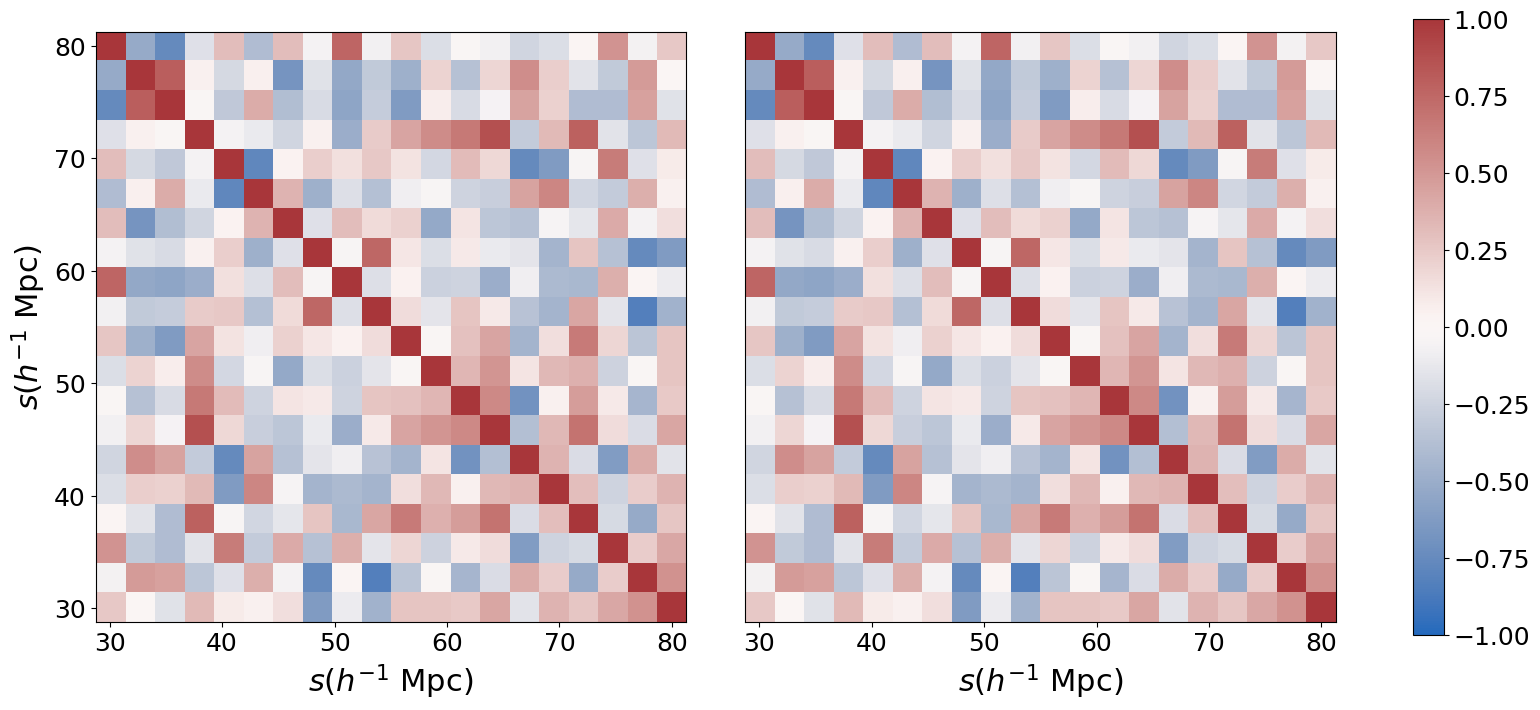

In [80]:
cmap = sns.color_palette("vlag", as_cmap=True)

# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0.1, hspace = 0.1)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

matrix = np.corrcoef(C_unmasked)
image = ax1.imshow(matrix, cmap = cmap, extent = [r[0], r[-1], r[0], r[-1]], vmin = -1, vmax = 1)
matrix = np.corrcoef(C_masked)
image = ax2.imshow(matrix, cmap = cmap, extent = [r[0], r[-1], r[0], r[-1]], vmin = -1, vmax = 1)
print(image.get_clim())
ax1.set_xlabel('$s (h^{-1}$ Mpc)')
ax2.set_xlabel('$s (h^{-1}$ Mpc)')
ax1.set_ylabel('$s (h^{-1}$ Mpc)')
ax2.set_yticks([])
    
fig.colorbar(image, ax = [ax1, ax2])
plt.show()

## Check the cosmology

In [81]:
C_unmasked = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25.npy'.format(G_hi, 30, 80, 20, j))
C_masked = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25_{}.npy'.format(G_hi, 30, 80, 20, j, cosmo))

In [82]:
np.max(C_unmasked-C_masked)

9.563796525941806e-06

(-1.0, 1.0)


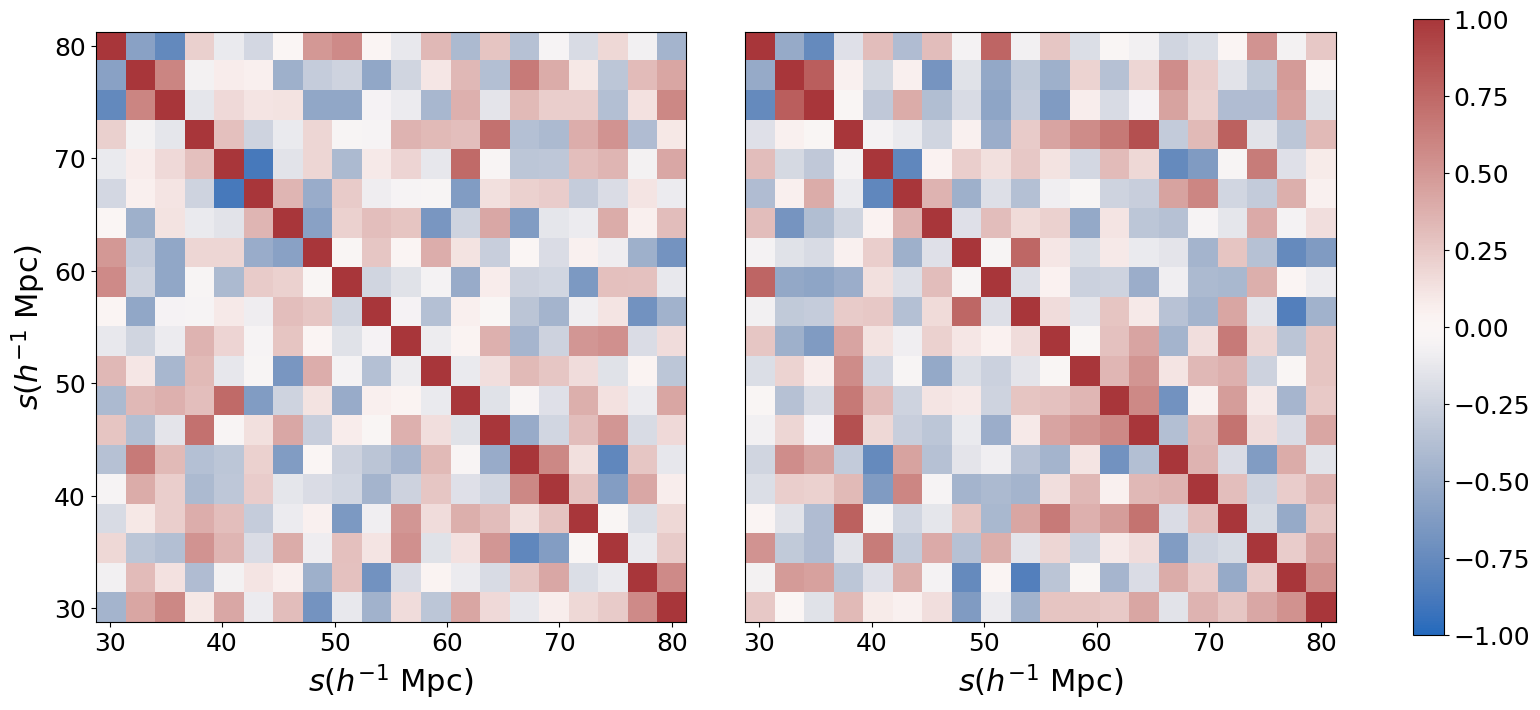

In [83]:
cmap = sns.color_palette("vlag", as_cmap=True)

# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0.1, hspace = 0.1)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

matrix = np.corrcoef(C_unmasked)
image = ax1.imshow(matrix, cmap = cmap, extent = [r[0], r[-1], r[0], r[-1]], vmin = -1, vmax = 1)
matrix = np.corrcoef(C_masked)
image = ax2.imshow(matrix, cmap = cmap, extent = [r[0], r[-1], r[0], r[-1]], vmin = -1, vmax = 1)
print(image.get_clim())
ax1.set_xlabel('$s (h^{-1}$ Mpc)')
ax2.set_xlabel('$s (h^{-1}$ Mpc)')
ax1.set_ylabel('$s (h^{-1}$ Mpc)')
ax2.set_yticks([])
    
fig.colorbar(image, ax = [ax1, ax2])
plt.show()

### Check the number of bins

In [172]:
C_unmasked = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N25_{}.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], cosmo))
C_masked = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25_{}.npy'.format(G_hi, 30, 80, 20, j, cosmo))

In [173]:
r = quaia.recenter(rbins_chi2) 
rpmask = (r >= 30) & (r  <= 80)
ix_grid = np.ix_(rpmask, rpmask)

In [174]:
np.max(C_unmasked[ix_grid]-C_masked)

7.551764857589067e-06

(-1.0, 1.0)


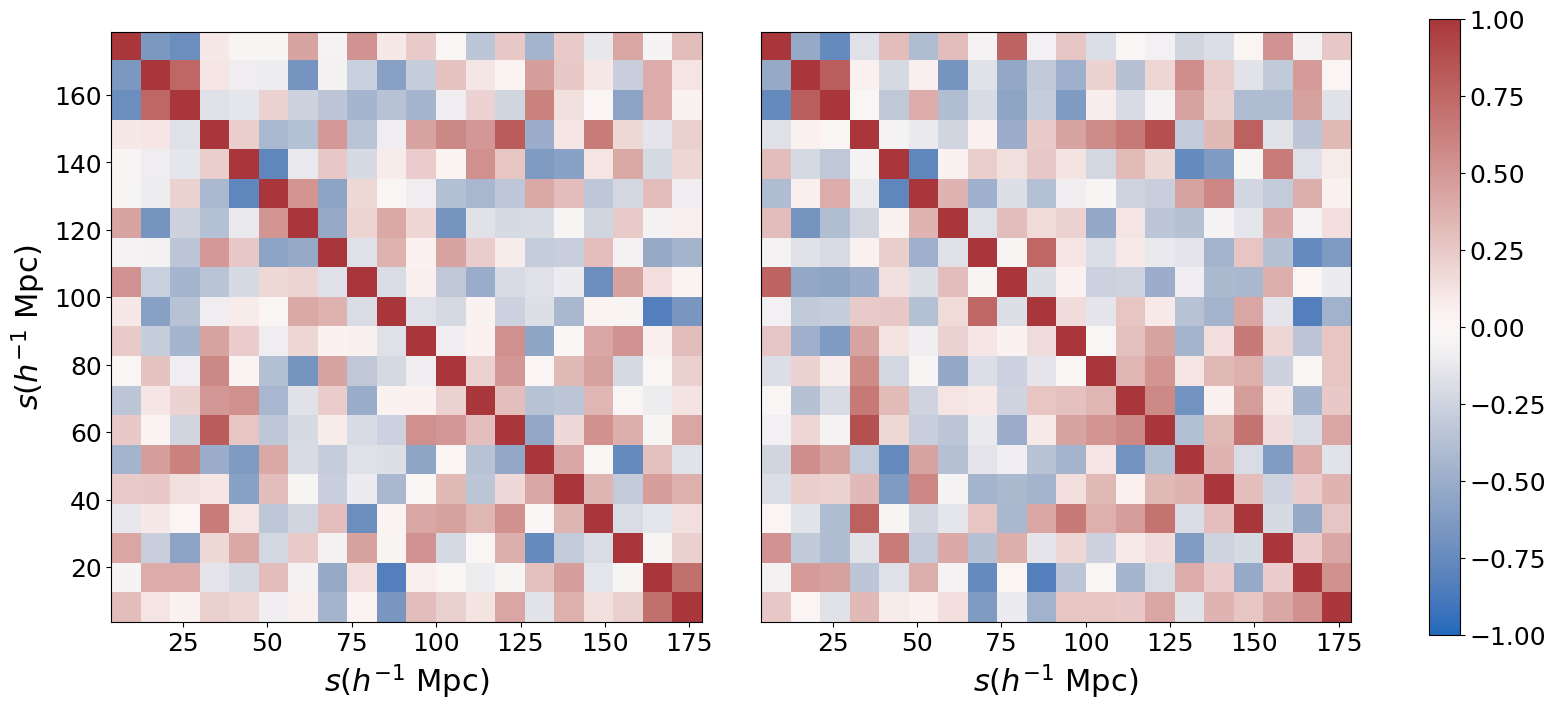

In [176]:
cmap = sns.color_palette("vlag", as_cmap=True)

# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0.1, hspace = 0.1)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

matrix = np.corrcoef(C_unmasked[ix_grid])
image = ax1.imshow(matrix, cmap = cmap, extent = [r[0], r[-1], r[0], r[-1]], vmin = -1, vmax = 1)
matrix = np.corrcoef(C_masked)
image = ax2.imshow(matrix, cmap = cmap, extent = [r[0], r[-1], r[0], r[-1]], vmin = -1, vmax = 1)
print(image.get_clim())
ax1.set_xlabel('$s (h^{-1}$ Mpc)')
ax2.set_xlabel('$s (h^{-1}$ Mpc)')
ax1.set_ylabel('$s (h^{-1}$ Mpc)')
ax2.set_yticks([])
    
fig.colorbar(image, ax = [ax1, ax2])
plt.show()